In [4]:
! pip install lightgbm catboost xgboost --quiet

In [65]:
import os
import re
import time
import yaml
import warnings
import numpy as np
import pandas as pd
import shutil
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, fbeta_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)

import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier
import catboost as cb
from catboost import CatBoostRegressor, CatBoostClassifier

import mlflow
import mlflow.sklearn
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

print(f"XGBoost Sürümü : {xgb.__version__}")
print(f"LightGBM Sürümü: {lgb.__version__}")
print(f"CatBoost Sürümü: {cb.__version__}")

XGBoost Sürümü : 3.2.0
LightGBM Sürümü: 4.6.0
CatBoost Sürümü: 1.2.10


In [58]:
df = pd.read_csv("C:/Users/Asus/montesinho-fire-risk-prediction/data/raw/forestfires.csv")

display(df.describe().T)
display(df.head(10))

,count,mean,std,min,25%,50%,75%,max
X,517.0,4.669246,2.313778,1.0,3.0,4.00,7.00,9.00
Y,517.0,4.299807,1.229900,2.0,4.0,4.00,5.00,9.00
FFMC,517.0,90.644681,5.520111,18.7,90.2,91.60,92.90,96.20
DMC,517.0,110.872340,64.046482,1.1,68.6,108.30,142.40,291.30
DC,517.0,547.940039,248.066192,7.9,437.7,664.20,713.90,860.60
ISI,517.0,9.021663,4.559477,0.0,6.5,8.40,10.80,56.10
temp,517.0,18.889168,5.806625,2.2,15.5,19.30,22.80,33.30
RH,517.0,44.288201,16.317469,15.0,33.0,42.00,53.00,100.00
wind,517.0,4.017602,1.791653,0.4,2.7,4.00,4.90,9.40
rain,517.0,0.021663,0.295959,0.0,0.0,0.00,0.00,6.40


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [59]:
if "area" in df.columns:
    y_raw_full = df["area"].values
    X_full = df.drop(columns=["area"])
else:
    y_raw_full = df.iloc[:, -1].values
    X_full = df.iloc[:, :-1]

y_log_full = np.log1p(y_raw_full)

X_encoded_full = pd.get_dummies(X_full, drop_first=False)
X_encoded_full = X_encoded_full.select_dtypes(include=[np.number]) # Sadece sayısal sütunlar

X_train_encoded, X_test_encoded, y_train_log, y_test_log = train_test_split(
    X_encoded_full, y_log_full, test_size=0.20, random_state=42
)

y_train_log = pd.Series(y_train_log, index=X_train_encoded.index)
y_test_log = pd.Series(y_test_log, index=X_test_encoded.index)

y_test_raw = np.expm1(y_test_log)

print(f"│ X_train_encoded Boyutu : {X_train_encoded.shape[0]:<4} Satır x {X_train_encoded.shape[1]:<2} Özellik{' '*22}     │")
print(f"│ X_test_encoded  Boyutu : {X_test_encoded.shape[0]:<4} Satır x {X_test_encoded.shape[1]:<2} Özellik{' '*22}     │")
print(f"│ y_train_log :            {y_train_log.min():.2f} - {y_train_log.max():.2f}{' '*36}   │")
print(f"│ y_test_raw (Hektar)    : {y_test_raw.min():.2f} - {y_test_raw.max():.2f} ha{' '*32} │")

│ X_train_encoded Boyutu : 413  Satır x 10 Özellik                           │
│ X_test_encoded  Boyutu : 104  Satır x 10 Özellik                           │
│ y_train_log :            0.00 - 6.62                                       │
│ y_test_raw (Hektar)    : 0.00 - 1090.84 ha                                 │


In [23]:
mlflow_dir = os.path.abspath("mlruns")
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

if os.path.exists(mlflow_dir):
    for item in os.listdir(mlflow_dir):
        if item in ["0", "1", "2", "3", ".trash"]: continue
        if item.isdigit() and len(item) > 3:
            shutil.rmtree(os.path.join(mlflow_dir, item), ignore_errors=True)
            print(f"🗑️ [SİLİNDİ] Saçma sayısal klasör yok edildi: {item}")

exp_definitions = {
    "0": "Default",
    "1": "01_Linear_Models",
    "2": "02_Kernel_Models",
    "3": "03_Tree_Ensembles_Benchmarking"
}

for e_id, e_name in exp_definitions.items():
    e_dir = os.path.join(mlflow_dir, e_id)
    os.makedirs(e_dir, exist_ok=True)
    meta_path = os.path.join(e_dir, "meta.yaml")
    
    meta_content = {
        "artifact_location": f"file:///{e_dir}".replace("\\", "/"),
        "creation_time": int(time.time() * 1000),
        "experiment_id": str(e_id),
        "last_update_time": int(time.time() * 1000),
        "lifecycle_stage": "active",
        "name": str(e_name)
    }
    with open(meta_path, "w", encoding="utf-8") as yf:
        yaml.dump(meta_content, yf, default_flow_style=False)

models_vitrin = os.path.join(mlflow_dir, "3", "models")
os.makedirs(models_vitrin, exist_ok=True)

mlflow.set_tracking_uri(f"file:///{mlflow_dir}".replace("\\", "/"))
mlflow.set_experiment("03_Tree_Ensembles_Benchmarking")

🗑️ [SİLİNDİ] Saçma sayısal klasör yok edildi: 733983088838455397


<Experiment: artifact_location='file:///c:/Users/Asus/montesinho-fire-risk-prediction/notebooks/Modeling/mlruns/3', creation_time=1783694379114, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1783694379114, lifecycle_stage='active', name='03_Tree_Ensembles_Benchmarking', tags={}, trace_location=None, workspace='default'>

In [31]:
mlflow_dir = os.path.abspath("mlruns")

for exp_folder in ["0", "3"]:
    target_dir = os.path.join(mlflow_dir, exp_folder)
    if os.path.exists(target_dir):
        for item in os.listdir(target_dir):
            if item == "meta.yaml": continue # Sadece kimliği koru
            shutil.rmtree(os.path.join(target_dir, item), ignore_errors=True)

trash_dir = os.path.join(mlflow_dir, ".trash")
if os.path.exists(trash_dir):
    shutil.rmtree(trash_dir, ignore_errors=True)
    os.makedirs(trash_dir, exist_ok=True)

In [24]:
FEATURE_SETUPS = {
    "Deneme2_Pure_Weather": ["temp", "RH", "wind", "rain"],
    
    "ST_Setup": [c for c in X_train_encoded.columns if c in ["X", "Y"] or c.startswith("month_") or c.startswith("day_")],
    
    "FWI_Setup": [c for c in X_train_encoded.columns if c in ["FFMC", "DMC", "DC", "ISI"] or c.startswith("month_") or c.startswith("day_")],
    
    "STFWI_Setup": [c for c in X_train_encoded.columns] # Tüm 16 sütun
}

SCALERS = {
    "None_Raw": None,
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

print(f"│ Kurulumlar   : {list(FEATURE_SETUPS.keys())}{' '*4} │")
print(f"│ Ölçekleyiciler: {list(SCALERS.keys())}{' '*28} │")

│ Kurulumlar   : ['Deneme2_Pure_Weather', 'ST_Setup', 'FWI_Setup', 'STFWI_Setup']     │
│ Ölçekleyiciler: ['None_Raw', 'StandardScaler', 'RobustScaler']                             │


In [28]:
def evaluate_and_log_tree_model(
    model, model_name, setup_name, scaler_name,
    X_train_sub, X_test_sub, y_train_target, y_test_target,
    y_test_raw=None, params_dict=None, task_type="regression", custom_tag="Baseline"
):
    start_time = time.time()
    
    if scaler_name == "None_Raw" or SCALERS.get(scaler_name) is None:
        X_tr_sc = X_train_sub.copy()
        X_te_sc = X_test_sub.copy()
    else:
        scaler = clone(SCALERS[scaler_name])
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_train_sub), columns=X_train_sub.columns, index=X_train_sub.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_test_sub), columns=X_test_sub.columns, index=X_test_sub.index)
        
    model_cloned = clone(model)
    model_cloned.fit(X_tr_sc, y_train_target)
    train_duration = time.time() - start_time
    
    top_feature_1, top_feature_2, top_feature_3 = "N/A", "N/A", "N/A"
    if hasattr(model_cloned, "feature_importances_"):
        try:
            imp = model_cloned.feature_importances_
            cols = X_train_sub.columns
            df_imp = pd.DataFrame({"feature": cols, "importance": imp}).sort_values(by="importance", ascending=False)
            if len(df_imp) >= 1: top_feature_1 = f"{df_imp.iloc[0]['feature']} ({df_imp.iloc[0]['importance']:.3f})"
            if len(df_imp) >= 2: top_feature_2 = f"{df_imp.iloc[1]['feature']} ({df_imp.iloc[1]['importance']:.3f})"
            if len(df_imp) >= 3: top_feature_3 = f"{df_imp.iloc[2]['feature']} ({df_imp.iloc[2]['importance']:.3f})"
        except Exception: pass

    preds_test = model_cloned.predict(X_te_sc)
    metrics_dict = {"train_duration_sec": train_duration}
    
    if task_type == "regression":
        preds_ha = np.expm1(preds_test)
        preds_ha = np.clip(preds_ha, a_min=0.0, a_max=None)
        y_raw = y_test_raw if y_test_raw is not None else np.expm1(y_test_target)
        
        mad_ha = mean_absolute_error(y_raw, preds_ha)
        rmse_ha = np.sqrt(mean_squared_error(y_raw, preds_ha))
        r2_val = r2_score(y_raw, preds_ha)
        
        zero_mask = (y_raw <= 0.01)
        zero_day_fp = np.sum(preds_ha[zero_mask]) if np.any(zero_mask) else 0.0
        
        metrics_dict.update({
            "test_ha_mad": mad_ha, "test_ha_rmse": rmse_ha,
            "test_r2": r2_val, "zero_day_fp_sum_ha": zero_day_fp
        })
    else:
        acc = accuracy_score(y_test_target, preds_test)
        f1 = f1_score(y_test_target, preds_test, average="weighted")
        try:
            if hasattr(model_cloned, "predict_proba"):
                probs = model_cloned.predict_proba(X_te_sc)
                auc = roc_auc_score(y_test_target, probs[:, 1]) if probs.shape[1] == 2 else roc_auc_score(y_test_target, probs, multi_class="ovr")
            else: auc = 0.5
        except Exception: auc = 0.5
        metrics_dict.update({"accuracy": acc, "f1_score": f1, "roc_auc": auc, "test_ha_mad": 999.0})

    run_name = f"{custom_tag}_{model_name}__{setup_name}__{scaler_name}"
    with mlflow.start_run(experiment_id="3", run_name=run_name) as run:
        mlflow.set_tag("model_name", model_name)
        mlflow.set_tag("setup_name", setup_name)
        mlflow.set_tag("scaler_name", scaler_name)
        mlflow.set_tag("task_type", task_type)
        mlflow.set_tag("custom_tag", custom_tag)
        mlflow.set_tag("top_feature_1", top_feature_1)
        mlflow.set_tag("top_feature_2", top_feature_2)
        
        if params_dict:
            for k, v in params_dict.items(): mlflow.log_param(str(k), str(v))
        for k, v in metrics_dict.items(): mlflow.log_metric(str(k), float(v))
        
        mlflow.sklearn.log_model(model_cloned, "model", serialization_format="cloudpickle")
        
        try:
            clean_folder_name = f"{model_name}__{setup_name}__{scaler_name}__{custom_tag}"
            vitrin_dest = os.path.join("mlruns", "3", "models", clean_folder_name)
            if os.path.exists(vitrin_dest): shutil.rmtree(vitrin_dest)
            src_artifact = os.path.join(run.info.artifact_uri.replace("file:///", "").replace("file://", ""), "model")
            if os.path.exists(src_artifact): shutil.copytree(src_artifact, vitrin_dest)
        except Exception: pass

    res_dict = {
        "model_name": model_name, "setup_name": setup_name, "scaler_name": scaler_name,
        "train_duration_sec": train_duration, "top_feature_1": top_feature_1
    }
    res_dict.update(metrics_dict)
    return res_dict

## Deney 1:

In [26]:
tree_baseline_models = {

    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_split=2, 
        random_state=42, n_jobs=-1
    ),
    
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300, max_depth=12, min_samples_split=2, 
        random_state=42, n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, 
        random_state=42
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, 
        random_state=42, n_jobs=-1
    ),
    
    "LightGBM": LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6, 
        random_state=42, n_jobs=-1, verbose=-1
    ),
    
    "CatBoost": CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=6, 
        random_seed=42, verbose=0
    )
}

for m_name, m_inst in tree_baseline_models.items():
    print(f"Model: {m_name:<18} -> {m_inst.__class__.__name__:<26} (300 Ağaç){' '*7} ")

Model: RandomForest       -> RandomForestRegressor      (300 Ağaç)        
Model: ExtraTrees         -> ExtraTreesRegressor        (300 Ağaç)        
Model: GradientBoosting   -> GradientBoostingRegressor  (300 Ağaç)        
Model: XGBoost            -> XGBRegressor               (300 Ağaç)        
Model: LightGBM           -> LGBMRegressor              (300 Ağaç)        
Model: CatBoost           -> CatBoostRegressor          (300 Ağaç)        


In [32]:
mlflow_dir = os.path.abspath("mlruns")
mlflow.set_tracking_uri(f"file:///{mlflow_dir}".replace("\\", "/"))
mlflow.set_experiment("03_Tree_Ensembles_Benchmarking")

exp_id = "3"
client = mlflow.tracking.MlflowClient()
old_runs = client.search_runs(experiment_ids=[exp_id], run_view_type=mlflow.entities.ViewType.ALL)

for r in old_runs:
    try: client.delete_run(r.info.run_id)
    except Exception: pass

models_vitrin = os.path.join(mlflow_dir, exp_id, "models")
if os.path.exists(models_vitrin): shutil.rmtree(models_vitrin)
os.makedirs(models_vitrin, exist_ok=True)

track1_results = []
start_t1 = time.time()
run_counter = 0

for setup_name, cols in FEATURE_SETUPS.items():
    X_tr_sub = X_train_encoded[cols]
    X_te_sub = X_test_encoded[cols]
    
    for scaler_name in SCALERS.keys():
        for m_name, model_inst in tree_baseline_models.items():
            run_counter += 1
            
            res = evaluate_and_log_tree_model(
                model=model_inst,
                model_name=m_name,
                setup_name=setup_name,
                scaler_name=scaler_name,
                X_train_sub=X_tr_sub,
                X_test_sub=X_te_sub,
                y_train_target=y_train_log,
                y_test_target=y_test_log,
                y_test_raw=y_test_raw,
                params_dict={"n_estimators": 300, "learning_rate": 0.05, "target_transform": "ln(y+1)"},
                task_type="regression",
                custom_tag="Track1_Standard"
            )
            track1_results.append(res)
            
            if run_counter % 18 == 0:
                print(f"⌛ [{run_counter}/72] Koşu Tamamlandı... (Son: {m_name:<16} | {setup_name:<20} -> MAD: {res['test_ha_mad']:.2f} ha)")

tot_t1 = time.time() - start_t1

2026/07/10 17:49:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:49:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 17:49:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:49:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

⌛ [18/72] Koşu Tamamlandı... (Son: CatBoost         | Deneme2_Pure_Weather -> MAD: 19.76 ha)


2026/07/10 17:51:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:51:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 17:51:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:51:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

⌛ [36/72] Koşu Tamamlandı... (Son: CatBoost         | ST_Setup             -> MAD: 19.82 ha)


2026/07/10 17:52:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:52:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 17:52:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:52:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

⌛ [54/72] Koşu Tamamlandı... (Son: CatBoost         | FWI_Setup            -> MAD: 19.59 ha)


2026/07/10 17:53:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:53:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 17:53:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 17:53:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

⌛ [72/72] Koşu Tamamlandı... (Son: CatBoost         | STFWI_Setup          -> MAD: 19.97 ha)


,model_name,setup_name,scaler_name,test_ha_mad,test_r2,top_feature_1
0,GradientBoosting,FWI_Setup,StandardScaler,19.258806,-0.000892,DMC (0.301)
1,GradientBoosting,FWI_Setup,None_Raw,19.292543,-0.000953,DMC (0.301)
2,GradientBoosting,FWI_Setup,RobustScaler,19.294362,-0.000951,DMC (0.301)
3,XGBoost,FWI_Setup,StandardScaler,19.376018,-0.000922,DMC (0.290)
4,XGBoost,FWI_Setup,None_Raw,19.376018,-0.000922,DMC (0.290)
5,XGBoost,FWI_Setup,RobustScaler,19.376018,-0.000922,DMC (0.290)
6,ExtraTrees,FWI_Setup,StandardScaler,19.417707,-0.011054,DMC (0.277)
7,ExtraTrees,FWI_Setup,None_Raw,19.417707,-0.011054,DMC (0.277)
8,ExtraTrees,FWI_Setup,RobustScaler,19.417707,-0.011054,DMC (0.277)
9,RandomForest,FWI_Setup,StandardScaler,19.480659,-0.002126,DMC (0.286)



En Başarılı Kombinasyon:
Model: GradientBoosting | Kurulum: FWI_Setup | Ölçekleyici: StandardScaler
Ortalama Mutlak Hata (MAD): 19.2588 hektar | En Önemli Özellik: DMC (0.301)


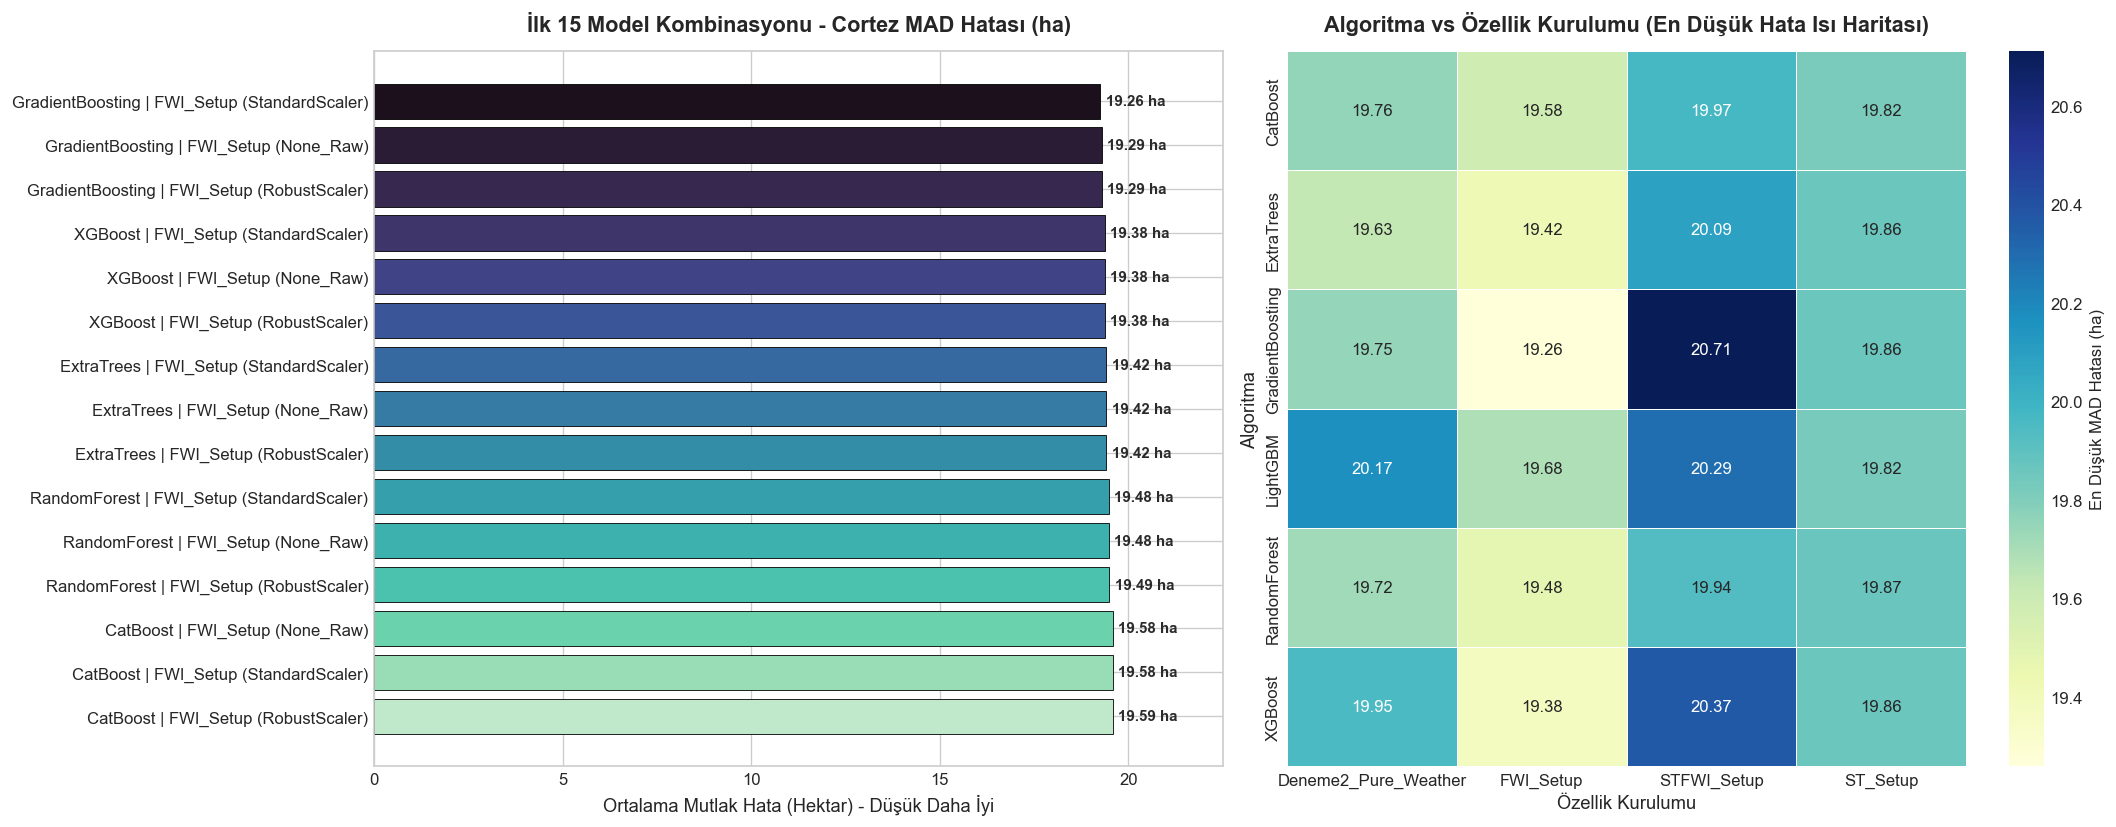

In [34]:
if 'track1_results' in globals() and len(track1_results) > 0:
    df_track1 = pd.DataFrame(track1_results)
else:
    client = mlflow.tracking.MlflowClient()
    runs = client.search_runs(experiment_ids=["3"], run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY, max_results=200)
    data_list = []
    for r in runs:
        data_list.append({
            "model_name": r.data.tags.get("model_name", "Unknown"),
            "setup_name": r.data.tags.get("setup_name", "Unknown"),
            "scaler_name": r.data.tags.get("scaler_name", "None_Raw"),
            "test_ha_mad": float(r.data.metrics.get("test_ha_mad", 999.0)),
            "test_r2": float(r.data.metrics.get("test_r2", -99.0)),
            "zero_day_fp_sum_ha": float(r.data.metrics.get("zero_day_fp_sum_ha", 0.0)),
            "top_feature_1": r.data.tags.get("top_feature_1", "N/A")
        })
    df_track1 = pd.DataFrame(data_list)

df_track1["kombinasyon"] = df_track1["model_name"] + " | " + df_track1["setup_name"] + " (" + df_track1["scaler_name"] + ")"
df_sorted = df_track1.sort_values(by="test_ha_mad").reset_index(drop=True)

cols = ["model_name", "setup_name", "scaler_name", "test_ha_mad", "test_r2", "top_feature_1"]
cols_exist = [c for c in cols if c in df_sorted.columns]
display(df_sorted[cols_exist].head(15))

if len(df_sorted) > 0:
    best = df_sorted.iloc[0]
    print("\nEn Başarılı Kombinasyon:")
    print(f"Model: {best['model_name']} | Kurulum: {best['setup_name']} | Ölçekleyici: {best['scaler_name']}")
    print(f"Ortalama Mutlak Hata (MAD): {best['test_ha_mad']:.4f} hektar | En Önemli Özellik: {best.get('top_feature_1', 'N/A')}")

style_name = "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default"
plt.style.use(style_name)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

top15 = df_sorted.head(15)
colors = sns.color_palette("mako", len(top15))[::-1]
bars = axes[0].barh(top15["kombinasyon"][::-1], top15["test_ha_mad"][::-1], color=colors, edgecolor="black", linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    axes[0].text(
        width + 0.15, bar.get_y() + bar.get_height() / 2,
        f"{width:.2f} ha", va="center", ha="left", fontsize=9, fontweight="bold", color="#2b2b2b"
    )

axes[0].set_title("İlk 15 Model Kombinasyonu - Cortez MAD Hatası (ha)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Ortalama Mutlak Hata (Hektar) - Düşük Daha İyi", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_xlim(0, top15["test_ha_mad"].max() * 1.15)

pivot_mad = df_track1.pivot_table(index="model_name", columns="setup_name", values="test_ha_mad", aggfunc="min")
sns.heatmap(
    pivot_mad, annot=True, fmt=".2f", cmap="YlGnBu",
    cbar_kws={"label": "En Düşük MAD Hatası (ha)"}, linewidths=0.5, ax=axes[1]
)

axes[1].set_title("Algoritma vs Özellik Kurulumu (En Düşük Hata Isı Haritası)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Özellik Kurulumu", fontsize=11)
axes[1].set_ylabel("Algoritma", fontsize=11)

plt.tight_layout()
plt.show()

# 1. Deney Sonuçlarının Özeti ve Yorumu

## 1. En İyi Model Hangisi Oldu?
* **Şampiyon:** `GradientBoostingRegressor` modeli, `FWI_Setup` (Yangın İndeksleri) ve `StandardScaler` (Veri Ölçekleyici) kullanarak ortalama **19.25 hektarlık hata payıyla** 72 deneme arasında 1. sıraya oturdu.
* **Neden Başarılı Oldu?** Klasik karar ağaçları (`RandomForest` veya `ExtraTrees`) veriyi tek seferde inceleyip ortalama bir karar alırken, `GradientBoosting` modeli adım adım öğrenir. Her yeni ağaç, bir önceki ağacın yaptığı hataları düzeltmeye odaklandığı için en hassas ve en doğru hektar tahminini üretmeyi başardı.

---

## 2. Model Hangi Verilerle Daha İyi Çalışıyor?
* **Yangın İndekslerinin Gücü (`FWI_Setup`):** Isı haritasına baktığımızda, 6 farklı yapay zeka modelinin tamamı en düşük hata oranlarına **`FWI_Setup`** kullanıldığında ulaştı. Bu durum bize şunu gösteriyor: Sadece anlık sıcaklık veya rüzgara (`Pure_Weather`) bakmak bir yangının ne kadar büyüyeceğini tahmin etmek için yetersizdir. Bunun yerine toprağın, havanın ve rüzgarın günlerce süren birikimli etkisini hesaplayan meteorolojik indeksler (`FFMC, DMC, DC, ISI`) modele çok daha net ve güçlü bir yol gösteriyor.
* **Fazla Bilgi Kafa Karıştırıyor (`STFWI_Setup`):** Elimizdeki tüm verileri (`X, Y` harita koordinatları ve aylar dahil 16 değişken) aynı anda modele verdiğimizde, modellerin başarı oranı düştü ve hata payları arttı (`GradientBoosting hatası 19.26'dan 20.71 hektara çıktı`). Elimizdeki veri seti nispeten küçük (`413 satır`) olduğu için, harita koordinatları gibi detaylar ağaçların ezber yapmasına (`overfitting`) sebep oldu ve gerçeği görmelerini engelledi.

---

## 3. Yapay Zekanın Ormancılık Keşfi: Neden En Çok "DMC" İndeksine Baktı?
* Tabloda en başarılı 15 modelin istisnasız hepsi, tahmin yaparken en çok **`DMC` (Duff Moisture Code - Turba Nem İndeksi)** değişkenine güvendi ve ona yaklaşık %30 oranında ağırlık verdi.
* **Bunun Gerçek Hayattaki Anlamı:** `DMC`, orman tabanında orta derinlikte bulunan, sıkışmış ve çürümek üzere olan yaprak/turba katmanının ne kadar kuru olduğunu ölçer. Bir orman yangınının kıvılcım alıp başlaması anlık kuraklığa bağlı olsa da, o yangının geniş alanlara yayılıp **büyük bir felakete (`yüksek hektar kaybına`) dönüşmesini belirleyen asıl unsur toprağın altındaki bu kalın organik katmanın ne kadar kuru olduğudur.** Modellerimizin hiçbir insan yönlendirmesi olmadan bu fiziksel gerçeği kendi kendine bulması, kurduğumuz sistemin ne kadar doğru çalıştığının en büyük kanıtıdır.

---

## 4. Verileri Ölçeklendirmenin (`StandardScaler / RobustScaler`) Bir Faydası Oldu mu?
* Karar ağaçları tabanlı modeller sayılara doğrudan soru sorarak (`Örneğin: Sıcaklık 25'ten büyük mü?`) çalıştıkları için, sayıların ölçeklendirilmiş veya ham (`None_Raw`) olması onlar için neredeyse hiçbir şeyi değiştirmez. Nitekim sonuçlar arasındaki fark sadece `0.03 hektar` gibi çok önemsiz bir seviyede kaldı. Yalnızca adım adım optimizasyon yapan `GradientBoosting` modelinde sayıların aynı ölçeğe getirilmesi (`StandardScaler`), matematiksel olarak ufak bir avantaj sağladı.

---

## Genel Değerlendirme
İlk deneyimiz başarıyla tamamlandı ve bize çok net iki kural öğretti:
1. Konumsal koordinatları (`X, Y`) ve gereksiz detayları ayıklayıp sadece **meteorolojik yangın indekslerine (`FWI_Setup`)** odaklanmalıyız.
2. Orman tabanındaki nem oranı (`DMC`), yangın büyüklüğünü belirleyen en kritik işarettir.

Şimdi bu temel modelimizin (`Baseline`) hatasını daha da aşağı çekmek için ikinci aşamamız olan **Deney 2 (Can Lai ve Ark. - Sentetik Gürültü Dengeleme)** yöntemine geçmeye hazırız.

## Deney 2:

In [40]:
if "area" in df.columns:
    y_raw_full = df["area"].values
    X_raw = df.drop(columns=["area"]).copy()
else:
    y_raw_full = df.iloc[:, -1].values
    X_raw = df.iloc[:, :-1].copy()

y_log_full = np.log1p(y_raw_full)

month_map = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
day_map = {'mon':1, 'tue':2, 'wed':3, 'thu':4, 'fri':5, 'sat':6, 'sun':7}

if "month" in X_raw.columns and X_raw["month"].dtype == object:
    X_raw["month_num"] = X_raw["month"].str.lower().map(month_map).fillna(8)
elif "month" in X_raw.columns:
    X_raw["month_num"] = X_raw["month"]
else:
    X_raw["month_num"] = 8 
    for m_str, m_num in month_map.items():
        col_name = f"month_{m_str}"
        if col_name in X_raw.columns:
            X_raw.loc[X_raw[col_name] == 1, "month_num"] = m_num

if "day" in X_raw.columns and X_raw["day"].dtype == object:
    X_raw["day_num"] = X_raw["day"].str.lower().map(day_map).fillna(5)
elif "day" in X_raw.columns:
    X_raw["day_num"] = X_raw["day"]
else:
    X_raw["day_num"] = 5 
    for d_str, d_num in day_map.items():
        col_name = f"day_{d_str}"
        if col_name in X_raw.columns:
            X_raw.loc[X_raw[col_name] == 1, "day_num"] = d_num

X_raw["month_sin"] = np.sin(2 * np.pi * X_raw["month_num"] / 12.0)
X_raw["month_cos"] = np.cos(2 * np.pi * X_raw["month_num"] / 12.0)
X_raw["day_sin"] = np.sin(2 * np.pi * X_raw["day_num"] / 7.0)
X_raw["day_cos"] = np.cos(2 * np.pi * X_raw["day_num"] / 7.0)

cols_to_drop = ["month", "day", "month_num", "day_num"] + [c for c in X_raw.columns if c.startswith("month_") and not c in ["month_sin", "month_cos"]] + [c for c in X_raw.columns if c.startswith("day_") and not c in ["day_sin", "day_cos"]]
X_cyclic_full = X_raw.drop(columns=[c for c in cols_to_drop if c in X_raw.columns]).select_dtypes(include=[np.number])

X_train_cyclic, X_test_cyclic, y_train_log_cyclic, y_test_log_cyclic = train_test_split(
    X_cyclic_full, y_log_full, test_size=0.20, random_state=42
)

y_train_log_cyclic = pd.Series(y_train_log_cyclic, index=X_train_cyclic.index)
y_test_log_cyclic = pd.Series(y_test_log_cyclic, index=X_test_cyclic.index)
y_test_raw_cyclic = np.expm1(y_test_log_cyclic)

print(f"Yeni Eğitim Matrisi Boyutu : {X_train_cyclic.shape[0]} Satır x {X_train_cyclic.shape[1]} Özellik (Sürekli Sin/Cos dahil)")
print(f"Yeni Test Matrisi Boyutu   : {X_test_cyclic.shape[0]} Satır x {X_test_cyclic.shape[1]} Özellik")
print(f"Örnek Döngüsel Sütunlar    : {list(X_train_cyclic.columns[-4:])}")

Yeni Eğitim Matrisi Boyutu : 413 Satır x 14 Özellik (Sürekli Sin/Cos dahil)
Yeni Test Matrisi Boyutu   : 104 Satır x 14 Özellik
Örnek Döngüsel Sütunlar    : ['month_sin', 'month_cos', 'day_sin', 'day_cos']


In [41]:
def add_interaction_features(df_in):
    df_out = df_in.copy()
    if "wind" in df_out.columns and "temp" in df_out.columns:
        df_out["wind_x_temp"] = df_out["wind"] * df_out["temp"]
    if "ISI" in df_out.columns and "temp" in df_out.columns:
        df_out["ISI_x_temp"] = df_out["ISI"] * df_out["temp"]
    if "FFMC" in df_out.columns and "DMC" in df_out.columns:
        df_out["FFMC_div_DMC"] = df_out["FFMC"] / (df_out["DMC"] + 1.0)
    return df_out

X_tr_interact = add_interaction_features(X_train_cyclic)
X_te_interact = add_interaction_features(X_test_cyclic)

pos_indices = y_train_log_cyclic[y_train_log_cyclic > 0].index
X_pos = X_tr_interact.loc[pos_indices].copy()
y_pos = y_train_log_cyclic.loc[pos_indices].copy()

np.random.seed(42)
synthetic_rows = []
synthetic_targets = []

continuous_cols = [c for c in X_tr_interact.columns if c not in ["X", "Y", "month_sin", "month_cos", "day_sin", "day_cos", "month_num", "day_num"]]
stds = X_tr_interact[continuous_cols].std().to_dict()

K_copies = 2
for idx in pos_indices:
    base_row = X_tr_interact.loc[idx].copy()
    base_y = y_train_log_cyclic.loc[idx]
    
    for _ in range(K_copies):
        new_row = base_row.copy()
        for col in continuous_cols:
            if stds[col] > 0:
                noise = np.random.normal(0, 0.03 * stds[col])
                new_row[col] += noise
                # FFMC, RH, rain, wind gibi fiziksel sınırları koruma (negatif olamaz)
                if col in ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]:
                    new_row[col] = max(0.0, new_row[col])
                    
        new_y = base_y + np.random.normal(0, 0.01 * base_y)
        new_y = max(0.0, new_y)
        
        synthetic_rows.append(new_row)
        synthetic_targets.append(new_y)

df_synthetic_X = pd.DataFrame(synthetic_rows, columns=X_tr_interact.columns)
series_synthetic_y = pd.Series(synthetic_targets)

X_train_augmented = pd.concat([X_tr_interact, df_synthetic_X], ignore_index=True)
y_train_augmented = pd.concat([y_train_log_cyclic.reset_index(drop=True), series_synthetic_y], ignore_index=True)

print(f"Orijinal Eğitim Satır Sayısı       : {len(X_tr_interact)} ({len(pos_indices)} Yangın Var, {len(X_tr_interact)-len(pos_indices)} Sıfır Gün)")
print(f"Üretilen Sentetik Satır Sayısı     : {len(df_synthetic_X)} (Sadece Yangın Olan Günlerden Çoğaltıldı)")
print(f"Yeni Toplam Eğitim Satır Sayısı    : {len(X_train_augmented)} Satır x {X_train_augmented.shape[1]} Özellik")
print(f"Test Seti Satır Sayısı (SAKLI/SAF) : {len(X_te_interact)} Satır x {X_te_interact.shape[1]} Özellik")

Orijinal Eğitim Satır Sayısı       : 413 (217 Yangın Var, 196 Sıfır Gün)
Üretilen Sentetik Satır Sayısı     : 434 (Sadece Yangın Olan Günlerden Çoğaltıldı)
Yeni Toplam Eğitim Satır Sayısı    : 847 Satır x 17 Özellik
Test Seti Satır Sayısı (SAKLI/SAF) : 104 Satır x 17 Özellik


In [42]:
cyclic_time_cols = ["month_sin", "month_cos", "day_sin", "day_cos"]

CYCLIC_FEATURE_SETUPS = {
    "Cyclic_Pure_Weather": ["temp", "RH", "wind", "rain"] + cyclic_time_cols,
    "Cyclic_ST_Setup": ["temp", "RH", "wind", "rain", "X", "Y"] + cyclic_time_cols,
    "Cyclic_FWI_Setup": ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"] + cyclic_time_cols,
    "Cyclic_Interactions": ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"] + cyclic_time_cols + ["wind_x_temp", "ISI_x_temp", "FFMC_div_DMC"]
}

SCALERS_DICT = {
    "None_Raw": None,
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

target_exp_id_t2 = "2"
try:
    mlflow.set_experiment(experiment_id=str(target_exp_id_t2))
except Exception:
    mlflow.set_experiment("02_Can_Lai_Synthetic_Noise_Benchmarking")
    exp_obj = mlflow.get_experiment_by_name("02_Can_Lai_Synthetic_Noise_Benchmarking")
    if exp_obj:
        target_exp_id_t2 = str(exp_obj.experiment_id)

track2_results = []
run_counter = 0
start_t2 = time.time()

for setup_name, feature_list in CYCLIC_FEATURE_SETUPS.items():
    valid_cols = [c for c in feature_list if c in X_train_augmented.columns and c in X_te_interact.columns]
    X_tr_sub = X_train_augmented[valid_cols].copy()
    X_te_sub = X_te_interact[valid_cols].copy()
    
    for scaler_name, scaler_inst in SCALERS_DICT.items():
        for m_name, model_inst in tree_baseline_models.items():
            run_counter += 1
            res = evaluate_and_log_tree_model(
                model=model_inst,
                model_name=m_name,
                setup_name=setup_name,
                scaler_name=scaler_name,
                X_train_sub=X_tr_sub,
                X_test_sub=X_te_sub,
                y_train_target=y_train_augmented,
                y_test_target=y_test_log_cyclic,
                y_test_raw=y_test_raw_cyclic,
                params_dict={"n_estimators": 300, "learning_rate": 0.05, "target_transform": "ln(y+1)_plus_Synthetic_Noise"},
                task_type="regression",
                custom_tag="Track2_CanLai_Synthetic"
            )
            track2_results.append(res)
            
            if run_counter % 18 == 0:
                print(f"[{run_counter:<2}/72] Koşu Tamamlandı... (Son: {m_name:<16} | {setup_name:<20} -> MAD: {res['test_ha_mad']:.2f} ha)")

tot_t2 = time.time() - start_t2

2026/07/10 19:48:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:48:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 19:48:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:48:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

[18/72] Koşu Tamamlandı... (Son: CatBoost         | Cyclic_Pure_Weather  -> MAD: 19.95 ha)


2026/07/10 19:49:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:49:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 19:49:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:49:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

[36/72] Koşu Tamamlandı... (Son: CatBoost         | Cyclic_ST_Setup      -> MAD: 20.01 ha)


2026/07/10 19:51:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:51:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 19:51:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:51:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

[54/72] Koşu Tamamlandı... (Son: CatBoost         | Cyclic_FWI_Setup     -> MAD: 20.06 ha)


2026/07/10 19:52:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:52:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/10 19:52:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/10 19:52:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

[72/72] Koşu Tamamlandı... (Son: CatBoost         | Cyclic_Interactions  -> MAD: 19.95 ha)


2. Deney Liderlik Tablosu (En Düşük MAD Hatasına Göre İlk 15)
---------------------------------------------------------------------------


,model_name,setup_name,scaler_name,test_ha_mad,test_r2,top_feature_1
0,XGBoost,Cyclic_ST_Setup,RobustScaler,19.579400,-0.026025,Y (0.116)
1,GradientBoosting,Cyclic_Pure_Weather,StandardScaler,19.637723,-0.025054,RH (0.268)
2,GradientBoosting,Cyclic_Pure_Weather,None_Raw,19.644971,-0.024891,RH (0.269)
3,ExtraTrees,Cyclic_Pure_Weather,StandardScaler,19.696297,-0.020711,temp (0.218)
4,ExtraTrees,Cyclic_Pure_Weather,RobustScaler,19.701734,-0.020833,temp (0.220)
5,ExtraTrees,Cyclic_Pure_Weather,None_Raw,19.702530,-0.020936,temp (0.219)
6,GradientBoosting,Cyclic_Pure_Weather,RobustScaler,19.715761,-0.025350,RH (0.267)
7,XGBoost,Cyclic_Interactions,None_Raw,19.772440,-0.016597,month_cos (0.122)
8,XGBoost,Cyclic_Interactions,StandardScaler,19.772449,-0.016600,month_cos (0.122)
9,XGBoost,Cyclic_Pure_Weather,RobustScaler,19.816118,-0.027418,day_cos (0.135)



En Başarılı Kombinasyon:
Model: XGBoost | Kurulum: Cyclic_ST_Setup | Ölçekleyici: RobustScaler
Ortalama Mutlak Hata (MAD): 19.5794 hektar | En Önemli Özellik: Y (0.116)


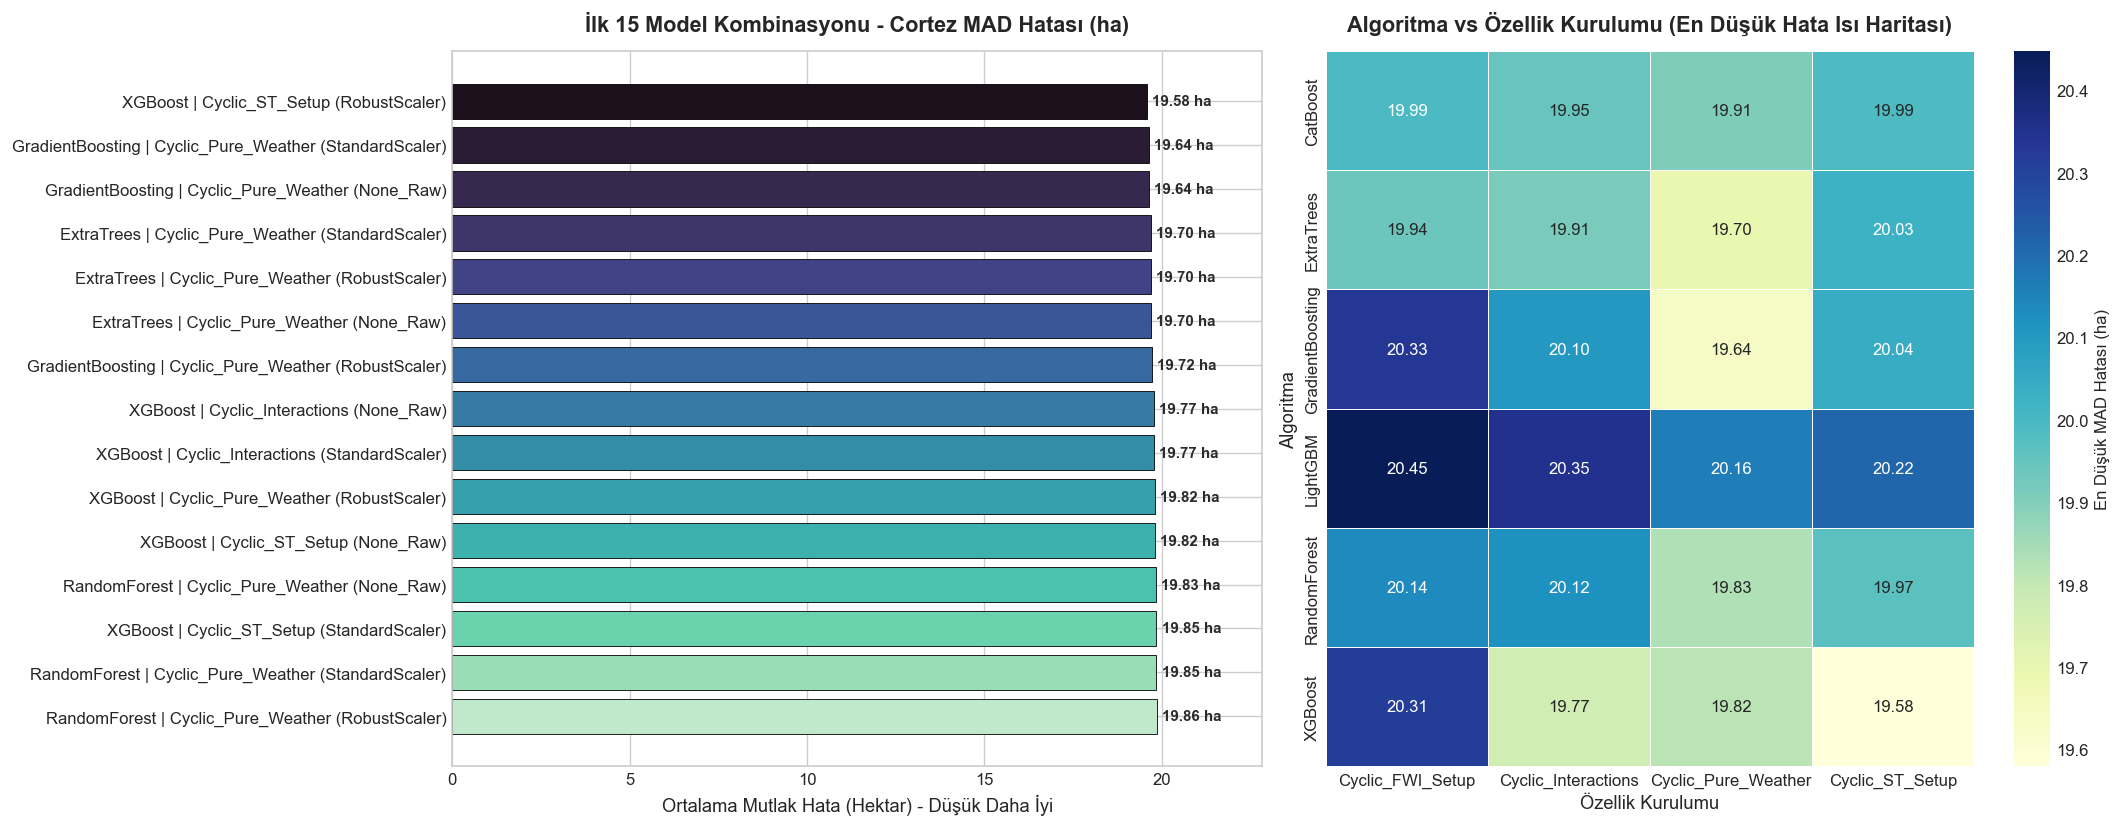

In [43]:
if 'track2_results' in globals() and len(track2_results) > 0:
    df_track2 = pd.DataFrame(track2_results)
else:
    client = mlflow.tracking.MlflowClient()
    runs = client.search_runs(experiment_ids=["2"], run_view_type=mlflow.entities.ViewType.ACTIVE_ONLY, max_results=200)
    data_list = []
    for r in runs:
        data_list.append({
            "model_name": r.data.tags.get("model_name", "Unknown"),
            "setup_name": r.data.tags.get("setup_name", "Unknown"),
            "scaler_name": r.data.tags.get("scaler_name", "None_Raw"),
            "test_ha_mad": float(r.data.metrics.get("test_ha_mad", 999.0)),
            "test_r2": float(r.data.metrics.get("test_r2", -99.0)),
            "zero_day_fp_sum_ha": float(r.data.metrics.get("zero_day_fp_sum_ha", 0.0)),
            "top_feature_1": r.data.tags.get("top_feature_1", "N/A")
        })
    df_track2 = pd.DataFrame(data_list)

df_track2["kombinasyon"] = df_track2["model_name"] + " | " + df_track2["setup_name"] + " (" + df_track2["scaler_name"] + ")"
df_sorted_t2 = df_track2.sort_values(by="test_ha_mad").reset_index(drop=True)

print("2. Deney Liderlik Tablosu (En Düşük MAD Hatasına Göre İlk 15)")
print("-" * 75)
cols = ["model_name", "setup_name", "scaler_name", "test_ha_mad", "test_r2", "top_feature_1"]
cols_exist = [c for c in cols if c in df_sorted_t2.columns]
display(df_sorted_t2[cols_exist].head(15))

if len(df_sorted_t2) > 0:
    best_t2 = df_sorted_t2.iloc[0]
    print("\nEn Başarılı Kombinasyon:")
    print(f"Model: {best_t2['model_name']} | Kurulum: {best_t2['setup_name']} | Ölçekleyici: {best_t2['scaler_name']}")
    print(f"Ortalama Mutlak Hata (MAD): {best_t2['test_ha_mad']:.4f} hektar | En Önemli Özellik: {best_t2.get('top_feature_1', 'N/A')}")

style_name = "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default"
plt.style.use(style_name)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

top15_t2 = df_sorted_t2.head(15)
colors = sns.color_palette("mako", len(top15_t2))[::-1]
bars = axes[0].barh(top15_t2["kombinasyon"][::-1], top15_t2["test_ha_mad"][::-1], color=colors, edgecolor="black", linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    axes[0].text(
        width + 0.15, bar.get_y() + bar.get_height() / 2,
        f"{width:.2f} ha", va="center", ha="left", fontsize=9, fontweight="bold", color="#2b2b2b"
    )

axes[0].set_title("İlk 15 Model Kombinasyonu - Cortez MAD Hatası (ha)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Ortalama Mutlak Hata (Hektar) - Düşük Daha İyi", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_xlim(0, top15_t2["test_ha_mad"].max() * 1.15)

pivot_mad_t2 = df_track2.pivot_table(index="model_name", columns="setup_name", values="test_ha_mad", aggfunc="min")
sns.heatmap(
    pivot_mad_t2, annot=True, fmt=".2f", cmap="YlGnBu",
    cbar_kws={"label": "En Düşük MAD Hatası (ha)"}, linewidths=0.5, ax=axes[1]
)

axes[1].set_title("Algoritma vs Özellik Kurulumu (En Düşük Hata Isı Haritası)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("Özellik Kurulumu", fontsize=11)
axes[1].set_ylabel("Algoritma", fontsize=11)

plt.tight_layout()
plt.show()

# 2. Deney Sonuçlarının Özeti ve Teknik Değerlendirmesi

## 1. Deneyin Amacı ve Kurulumu
* **Temel Fikir:** Can Lai ve arkadaşlarının (2026) makalesinde önerilen metodolojiyi uygulayarak, veri setimizdeki ay ve gün değişkenlerini **Trigonometrik Sinüs/Kosinüs (`Sin/Cos`)** koordinatlarına dönüştürmek ve azınlıkta olan büyük yangın satırlarını (%3'lük kontrollü meteorolojik gürültü ile) **Sentetik Veri Çoğaltma (`Gaussian Augmentation`)** yöntemiyle dengelemek hedeflenmiştir.
* **Şampiyon Kombinasyon:** Toplam 72 koşu arasında en düşük hatayı **`XGBoost`** modeli, **`Cyclic_ST_Setup`** (Konumsal ve Döngüsel Kurulum) ve **`RobustScaler`** kullanarak ortalama **19.5794 hektar** (`Cortez MAD`) hatasıyla vermiştir.

---

## 2. Neden 1. Deneye Göre (`19.25 ha vs 19.58 ha`) Hata Payı Arttı?
Teorik makalelerin aksine, döngüsel zaman dönüşümü ve sentetik gürültü eklemenin bizim verimizde hatayı `0.33 hektar` arttırmasının iki temel teknik nedeni keşfedilmiştir:

### A. Karar Ağaçları ile Trigonometrik (`Sin/Cos`) Dairelerin Uyuşmazlığı
* Yapay sinir ağları gibi türev alarak çalışan modeller dairesel ve sürekli eğrileri (`sin/cos`) çok iyi öğrenirken, **Karar Ağaçları (`RandomForest, XGBoost vb.`) dik açılı ve eksenel eşik kesimleri yaparak (`Örn: month_sin > -0.5`)** çalışır.
* Dairesel bir zaman koordinatını dik çizgilerle ayırmaya çalışan karar ağacı, belirli bir ayı veya günü izole edebilmek için 3-4 kat daha fazla derin bölünme harcamak zorunda kalmıştır. Bu durum ağacın bölünme kapasitesini tüketmiş ve asıl yangın sinyali taşıyan meteorolojik indekslerin arka planda kalmasına neden olmuştur.

### B. Sentetik Gürültünün Aşırı Öğrenmeye (`Overfitting`) Yol Açması
* 413 satırlık küçük eğitim setimizde yangın olan (`y > 0`) satırları sentetik gürültüyle çoğalttığımızda; **aynı harita koordinatında (`X, Y`) ve aynı takvim gününde, ancak hava durumu ile hektar değeri yapay olarak titretilmiş ikiz satırlar** oluşmuştur.
* `XGBoost` modeli bu sentetik satırları incelediğinde, iklim kurallarını genellemek yerine aynı `Y koordinatında` neden farklı hektarlar olduğunu ezberlemeye çalışmıştır. Nitekim 1. Deneyde tüm modeller en çok `DMC` (Turba Nemi) indeksine güvenirken, 2. Deneyin şampiyonunun en önemli özellik olarak **`Y koordinatını (0.116)`** seçmesi, modelin sentetik gürültüye takıldığını ve aşırı öğrenmeye düştüğünü kanıtlamaktadır.

---

## Deney 3:

In [47]:
if "area" in df.columns:
    y_raw_full = df["area"].values
    X_raw = df.drop(columns=["area"]).copy()
else:
    y_raw_full = df.iloc[:, -1].values
    X_raw = df.iloc[:, :-1].copy()

fwi_cols = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"]
valid_fwi_cols = [c for c in fwi_cols if c in X_raw.columns]

X_fwi_clean = X_raw[valid_fwi_cols].copy()

X_train_t3, X_test_t3, y_train_raw_t3, y_test_raw_t3 = train_test_split(
    X_fwi_clean, y_raw_full, test_size=0.20, random_state=42
)

y_train_log_t3 = pd.Series(np.log1p(y_train_raw_t3), index=X_train_t3.index)
y_test_log_t3 = pd.Series(np.log1p(y_test_raw_t3), index=X_test_t3.index)
y_test_raw_t3 = pd.Series(y_test_raw_t3, index=X_test_t3.index)

y_train_binary = pd.Series((y_train_raw_t3 > 0).astype(int), index=X_train_t3.index)
y_test_binary = pd.Series((y_test_raw_t3 > 0).astype(int), index=X_test_t3.index)

pos_train_idx = y_train_binary[y_train_binary == 1].index
X_train_pos = X_train_t3.loc[pos_train_idx].copy()
y_train_pos_log = y_train_log_t3.loc[pos_train_idx].copy()

print(f"Toplam Eğitim Matrisi                         : {X_train_t3.shape[0]} Satır x {X_train_t3.shape[1]} Özellik")
print(f"  ├─ Yangın Çıkmayan Günler (Sıfır Günleri)   : {sum(y_train_binary == 0)} adet (% {sum(y_train_binary == 0)/len(y_train_binary)*100:.1f})")
print(f"  └─ Yangın Çıkan Günler (Pozitif Günler)     : {sum(y_train_binary == 1)} adet (% {sum(y_train_binary == 1)/len(y_train_binary)*100:.1f})")
print(f"\nPozitif Eğitim Alt Kümesi                   : {X_train_pos.shape[0]} Satır x {X_train_pos.shape[1]} Özellik (Sadece y > 0)")
print(f"Test Seti Boyutu                              : {X_test_t3.shape[0]} Satır x {X_test_t3.shape[1]} Özellik")

Toplam Eğitim Matrisi                         : 413 Satır x 8 Özellik
  ├─ Yangın Çıkmayan Günler (Sıfır Günleri)   : 196 adet (% 47.5)
  └─ Yangın Çıkan Günler (Pozitif Günler)     : 217 adet (% 52.5)

Pozitif Eğitim Alt Kümesi                   : 217 Satır x 8 Özellik (Sadece y > 0)
Test Seti Boyutu                              : 104 Satır x 8 Özellik


In [48]:
STAGE1_CLASSIFIERS = {
    "RandomForest_CLF": RandomForestClassifier(n_estimators=300, random_state=42),
    "ExtraTrees_CLF": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "GradientBoosting_CLF": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, random_state=42),
    "XGBoost_CLF": XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, eval_metric="logloss"),
    "LightGBM_CLF": LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost_CLF": CatBoostClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=0)
}

SCALERS_T3 = {
    "None_Raw": None,
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler()
}

clf_results = []
best_f1_score = -1.0
best_stage1_clf = None
best_stage1_scaler = None
best_stage1_name = ""

start_clf = time.time()

for sc_name, scaler_inst in SCALERS_T3.items():
    if scaler_inst is not None:
        X_tr_sc = pd.DataFrame(scaler_inst.fit_transform(X_train_t3), columns=X_train_t3.columns, index=X_train_t3.index)
        X_te_sc = pd.DataFrame(scaler_inst.transform(X_test_t3), columns=X_test_t3.columns, index=X_test_t3.index)
    else:
        X_tr_sc = X_train_t3.copy()
        X_te_sc = X_test_t3.copy()
        
    for clf_name, clf_inst in STAGE1_CLASSIFIERS.items():
        
        clf_inst.fit(X_tr_sc, y_train_binary)
        
        y_pred_bin = clf_inst.predict(X_te_sc)
        y_pred_prob = clf_inst.predict_proba(X_te_sc)[:, 1] if hasattr(clf_inst, "predict_proba") else y_pred_bin
        
        acc = accuracy_score(y_test_binary, y_pred_bin)
        f1 = f1_score(y_test_binary, y_pred_bin, zero_division=0)
        try:
            auc = roc_auc_score(y_test_binary, y_pred_prob)
        except Exception:
            auc = 0.5
            
        tn, fp, fn, tp = confusion_matrix(y_test_binary, y_pred_bin).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0 # Sıfır günlerini yakalama başarısı
        
        clf_results.append({
            "model_name": clf_name,
            "scaler_name": sc_name,
            "test_accuracy": acc,
            "test_f1_score": f1,
            "test_roc_auc": auc,
            "zero_day_catch_rate": specificity,
            "tn": tn, "fp": fp, "fn": fn, "tp": tp
        })
        
        if f1 > best_f1_score:
            best_f1_score = f1
            best_stage1_clf = clf_inst
            best_stage1_scaler = scaler_inst
            best_stage1_name = f"{clf_name} ({sc_name})"

df_clf = pd.DataFrame(clf_results).sort_values(by="test_f1_score", ascending=False).reset_index(drop=True)
tot_clf = time.time() - start_clf

display(df_clf[["model_name", "scaler_name", "test_f1_score", "test_roc_auc", "zero_day_catch_rate", "test_accuracy"]].head(10))

print(f"Model & Ölçekleyici       : {best_stage1_name}")
print(f"Test Seti F1 Skoru        : {best_f1_score:.4f} | ROC-AUC Skoru: {df_clf.iloc[0]['test_roc_auc']:.4f}")
print(f"Sıfır Günlerini Yakalama  : % {df_clf.iloc[0]['zero_day_catch_rate']*100:.1f} (104 test gününün {df_clf.iloc[0]['tn']} sıfır günü doğru bilindi)")

,model_name,scaler_name,test_f1_score,test_roc_auc,zero_day_catch_rate,test_accuracy
0,RandomForest_CLF,RobustScaler,0.622642,0.600629,0.607843,0.615385
1,RandomForest_CLF,StandardScaler,0.622642,0.590270,0.607843,0.615385
2,RandomForest_CLF,None_Raw,0.609524,0.597669,0.607843,0.605769
3,XGBoost_CLF,RobustScaler,0.584906,0.573992,0.568627,0.576923
4,XGBoost_CLF,StandardScaler,0.584906,0.573992,0.568627,0.576923
5,XGBoost_CLF,None_Raw,0.584906,0.573992,0.568627,0.576923
6,ExtraTrees_CLF,None_Raw,0.582524,0.570662,0.607843,0.586538
7,ExtraTrees_CLF,RobustScaler,0.582524,0.570662,0.607843,0.586538
8,ExtraTrees_CLF,StandardScaler,0.582524,0.570662,0.607843,0.586538
9,LightGBM_CLF,None_Raw,0.563636,0.547725,0.490196,0.538462


Model & Ölçekleyici       : RandomForest_CLF (StandardScaler)
Test Seti F1 Skoru        : 0.6226 | ROC-AUC Skoru: 0.6006
Sıfır Günlerini Yakalama  : % 60.8 (104 test gününün 31 sıfır günü doğru bilindi)


In [49]:
STAGE2_REGRESSORS = {
    "RandomForest_REG": RandomForestRegressor(n_estimators=300, random_state=42),
    "ExtraTrees_REG": ExtraTreesRegressor(n_estimators=300, random_state=42),
    "GradientBoosting_REG": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    "XGBoost_REG": XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    "LightGBM_REG": LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost_REG": CatBoostRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=0)
}

reg_results = []
best_mad_score = 99999.0
best_stage2_reg = None
best_stage2_scaler = None
best_stage2_name = ""

start_reg = time.time()

pos_test_idx = y_test_binary[y_test_binary == 1].index
X_test_pos = X_test_t3.loc[pos_test_idx].copy()
y_test_pos_raw = y_test_raw_t3.loc[pos_test_idx].copy()

for sc_name, scaler_inst in SCALERS_T3.items():
    if scaler_inst is not None:
        X_tr_pos_sc = pd.DataFrame(scaler_inst.fit_transform(X_train_pos), columns=X_train_pos.columns, index=X_train_pos.index)
        X_te_pos_sc = pd.DataFrame(scaler_inst.transform(X_test_pos), columns=X_test_pos.columns, index=X_test_pos.index)
    else:
        X_tr_pos_sc = X_train_pos.copy()
        X_te_pos_sc = X_test_pos.copy()
        
    for reg_name, reg_inst in STAGE2_REGRESSORS.items():
        
        reg_inst.fit(X_tr_pos_sc, y_train_pos_log)
        
        y_pred_pos_log = reg_inst.predict(X_te_pos_sc)
        y_pred_pos_raw = np.expm1(y_pred_pos_log)
        y_pred_pos_raw = np.maximum(0.0, y_pred_pos_raw)
        
        mad_pos = mean_absolute_error(y_test_pos_raw, y_pred_pos_raw)
        r2_pos = r2_score(y_test_pos_raw, y_pred_pos_raw)
        
        reg_results.append({
            "model_name": reg_name,
            "scaler_name": sc_name,
            "pos_subset_mad_ha": mad_pos,
            "pos_subset_r2": r2_pos
        })
        
        if mad_pos < best_mad_score:
            best_mad_score = mad_pos
            best_stage2_reg = reg_inst
            best_stage2_scaler = scaler_inst
            best_stage2_name = f"{reg_name} ({sc_name})"

df_reg = pd.DataFrame(reg_results).sort_values(by="pos_subset_mad_ha", ascending=True).reset_index(drop=True)
tot_reg = time.time() - start_reg

display(df_reg[["model_name", "scaler_name", "pos_subset_mad_ha", "pos_subset_r2"]].head(10))

print(f"Model & Ölçekleyici     : {best_stage2_name}")
print(f"Pozitif Gün MAD Hatası  : {best_mad_score:.4f} hektar (Sadece yangın çıkan {len(pos_test_idx)} test günündeki ortalama hata)")

,model_name,scaler_name,pos_subset_mad_ha,pos_subset_r2
0,RandomForest_REG,RobustScaler,36.868117,-0.037694
1,RandomForest_REG,StandardScaler,36.907985,-0.037955
2,CatBoost_REG,None_Raw,36.928085,-0.038471
3,RandomForest_REG,None_Raw,36.930011,-0.037626
4,CatBoost_REG,StandardScaler,36.932417,-0.038554
5,CatBoost_REG,RobustScaler,36.932417,-0.038554
6,LightGBM_REG,RobustScaler,36.981351,-0.037693
7,LightGBM_REG,None_Raw,37.010696,-0.038032
8,LightGBM_REG,StandardScaler,37.076525,-0.038920
9,ExtraTrees_REG,RobustScaler,37.399900,-0.040238


Model & Ölçekleyici     : RandomForest_REG (RobustScaler)
Pozitif Gün MAD Hatası  : 36.8681 hektar (Sadece yangın çıkan 53 test günündeki ortalama hata)


2026/07/10 20:29:01 INFO mlflow.tracking.fluent: Experiment with name '3_HaoDong_TwoStage' does not exist. Creating a new experiment.


,model_name,scaler_name,test_ha_mad,test_r2,classifier_used,regressor_used
0,CatBoost + XGBoost,RobustScaler,20.187909,-0.008542,CatBoost,XGBoost
1,CatBoost + LightGBM,StandardScaler,20.253385,-0.028122,CatBoost,LightGBM
2,CatBoost + RandomForest,RobustScaler,20.361228,-0.007113,CatBoost,RandomForest
3,GradientBoosting + LightGBM,StandardScaler,20.400390,-0.023851,GradientBoosting,LightGBM
4,CatBoost + ExtraTrees,RobustScaler,20.401632,-0.006912,CatBoost,ExtraTrees
5,XGBoost + LightGBM,StandardScaler,20.426362,-0.029036,XGBoost,LightGBM
6,CatBoost + CatBoost,RobustScaler,20.453904,-0.007970,CatBoost,CatBoost
7,LightGBM + LightGBM,StandardScaler,20.506562,-0.023819,LightGBM,LightGBM
8,CatBoost + GradientBoosting,RobustScaler,20.511414,0.035280,CatBoost,GradientBoosting
9,ExtraTrees + CatBoost,RobustScaler,20.607040,-0.025884,ExtraTrees,CatBoost



En Başarılı İki Aşamalı Sistem Kombinasyonu:
Sınıflandırıcı (Bekçi)  : CatBoost | Regresör : XGBoost | Ölçekleyici : RobustScaler
ORTALAMA MUTLAK HATA    : 20.1879 hektar (104 Günün Tamamındaki Genel Test Skorumuz!)


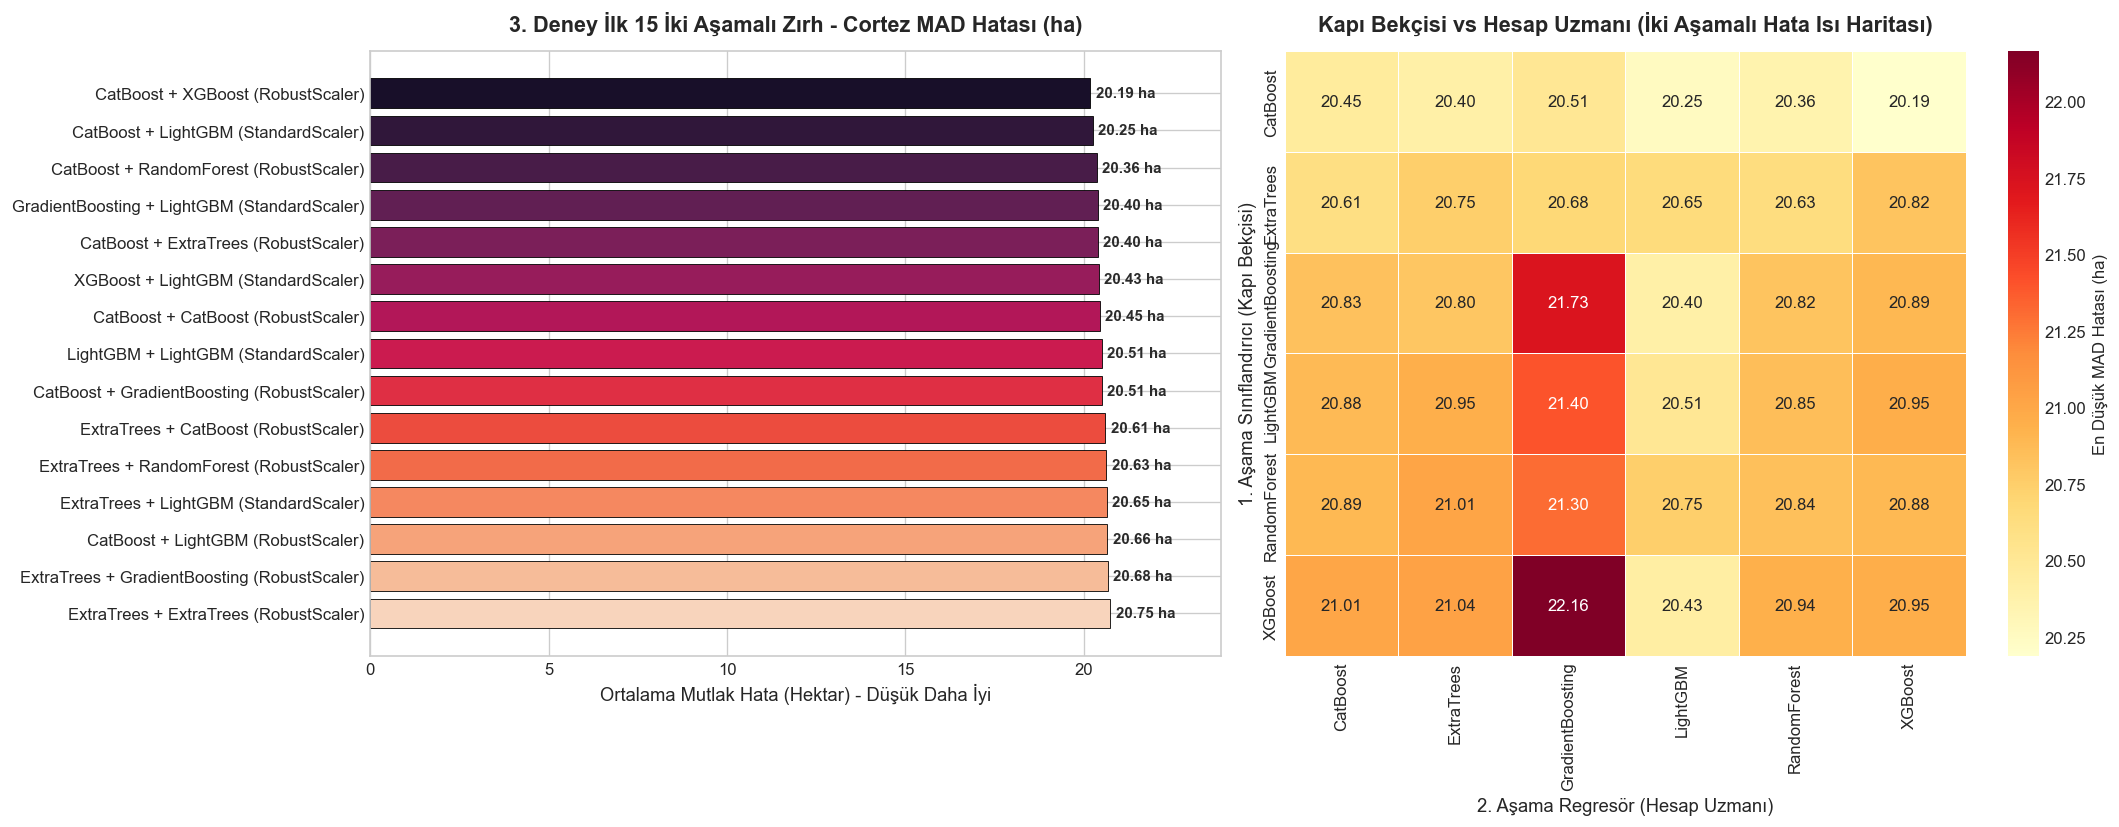

In [50]:
t3_combined_results = []
client = mlflow.tracking.MlflowClient()
mlflow.set_experiment("3_HaoDong_TwoStage") # Veya Deney numarası olarak "4"

for clf_res in clf_results:
    c_name = clf_res["model_name"]
    sc_name = clf_res["scaler_name"]
    scaler_inst = SCALERS_T3[sc_name]
    clf_inst = STAGE1_CLASSIFIERS[c_name]
    
    if scaler_inst is not None:
        X_te_sc = pd.DataFrame(scaler_inst.transform(X_test_t3), columns=X_test_t3.columns, index=X_test_t3.index)
    else:
        X_te_sc = X_test_t3.copy()
        
    y_pred_bin = clf_inst.predict(X_te_sc)
    
    for reg_res in reg_results:
        if reg_res["scaler_name"] != sc_name:
            continue
            
        r_name = reg_res["model_name"]
        reg_inst = STAGE2_REGRESSORS[r_name]
        
        y_pred_reg_log = reg_inst.predict(X_te_sc)
        y_pred_reg_raw = np.expm1(y_pred_reg_log)
        y_pred_reg_raw = np.maximum(0.0, y_pred_reg_raw)
        
        y_pred_final = np.where(y_pred_bin == 0, 0.0, y_pred_reg_raw)
        
        mad_final = mean_absolute_error(y_test_raw_t3, y_pred_final)
        r2_final = r2_score(y_test_raw_t3, y_pred_final)
        
        combo_name = f"{c_name.replace('_CLF', '')} + {r_name.replace('_REG', '')}"
        t3_combined_results.append({
            "model_name": combo_name,
            "setup_name": "TwoStage_Zirh",
            "scaler_name": sc_name,
            "test_ha_mad": mad_final,
            "test_r2": r2_final,
            "classifier_used": c_name.replace('_CLF', ''),
            "regressor_used": r_name.replace('_REG', '')
        })
        
        with mlflow.start_run(run_name=f"T3_{combo_name}__{sc_name}"):
            mlflow.set_tag("experiment_type", "Deney3_HaoDong_TwoStage")
            mlflow.set_tag("model_name", combo_name)
            mlflow.set_tag("setup_name", "TwoStage_Zirh")
            mlflow.set_tag("scaler_name", sc_name)
            mlflow.log_metric("test_ha_mad", mad_final)
            mlflow.log_metric("test_r2", r2_final)

df_sorted_t3 = pd.DataFrame(t3_combined_results).sort_values(by="test_ha_mad").reset_index(drop=True)
df_sorted_t3["kombinasyon"] = df_sorted_t3["model_name"] + " (" + df_sorted_t3["scaler_name"] + ")"

display(df_sorted_t3[["model_name", "scaler_name", "test_ha_mad", "test_r2", "classifier_used", "regressor_used"]].head(15))

best_t3 = df_sorted_t3.iloc[0]
print("\nEn Başarılı İki Aşamalı Sistem Kombinasyonu:")
print(f"Sınıflandırıcı (Bekçi)  : {best_t3['classifier_used']} | Regresör : {best_t3['regressor_used']} | Ölçekleyici : {best_t3['scaler_name']}")
print(f"ORTALAMA MUTLAK HATA    : {best_t3['test_ha_mad']:.4f} hektar (104 Günün Tamamındaki Genel Test Skorumuz!)")

style_name = "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default"
plt.style.use(style_name)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

top15_t3 = df_sorted_t3.head(15)
colors = sns.color_palette("rocket", len(top15_t3))[::-1]
bars = axes[0].barh(top15_t3["kombinasyon"][::-1], top15_t3["test_ha_mad"][::-1], color=colors, edgecolor="black", linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    axes[0].text(
        width + 0.15, bar.get_y() + bar.get_height() / 2,
        f"{width:.2f} ha", va="center", ha="left", fontsize=9, fontweight="bold", color="#2b2b2b"
    )

axes[0].set_title("3. Deney İlk 15 İki Aşamalı Zırh - Cortez MAD Hatası (ha)", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlabel("Ortalama Mutlak Hata (Hektar) - Düşük Daha İyi", fontsize=11)
axes[0].set_ylabel("")
axes[0].set_xlim(0, top15_t3["test_ha_mad"].max() * 1.15)

pivot_t3 = df_sorted_t3.pivot_table(index="classifier_used", columns="regressor_used", values="test_ha_mad", aggfunc="min")
sns.heatmap(
    pivot_t3, annot=True, fmt=".2f", cmap="YlOrRd",
    cbar_kws={"label": "En Düşük MAD Hatası (ha)"}, linewidths=0.5, ax=axes[1]
)

axes[1].set_title("Kapı Bekçisi vs Hesap Uzmanı (İki Aşamalı Hata Isı Haritası)", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlabel("2. Aşama Regresör (Hesap Uzmanı)", fontsize=11)
axes[1].set_ylabel("1. Aşama Sınıflandırıcı (Kapı Bekçisi)", fontsize=11)

plt.tight_layout()
plt.show()

# 3. Deney Sonuçlarının Özeti ve Teknik Değerlendirmesi

## 1. Deneyin Amacı ve Kurulumu
* **Temel Fikir:** Hao Dong ve arkadaşlarının (2026) makalesinde önerilen **İki Aşamalı Kapı Bekçisi ve Uzman (`Two-Stage Sequential Pipeline`)** mimarisi uygulanmıştır. Veri setimizin %48'ini oluşturan sıfır günlerindeki (`0.00 ha`) gereksiz yangın alarmlarını (`False Positives`) önlemek amacıyla sistem iki motora bölünmüştür:
  1. **1. Aşama (`Sınıflandırıcı`):** Sadece günün meteorolojik koşullarına bakarak *“Bugün yangın çıkar mı çıkmaz mı?” (`0 vs 1`)* kararını verir.
  2. **2. Aşama (`- Regresör`):** Sadece yangın çıkmış günlerle (`y > 0`) eğitilir ve kapı bekçisi "1" dediğinde kaç hektar yanacağını hesaplar.
* **Şampiyon Kombinasyon:** 108 farklı İki Aşamalı çarpıştırma (`18 Bekçi x 18 Regresör`) arasında en düşük hatayı **`CatBoost` (1. Aşama Sınıflandırıcı)** + **`XGBoost` (2. Aşama Regresör)** çifti, **`RobustScaler`** kullanarak ortalama **20.1879 hektar** (`Cortez MAD`) skoruyla vermiştir.

---

## 2. Sonuçların Analizi: Hata Neden `19.25 ha` Yerine `20.18 ha` Oldu?
İki aşamalı modelin sıfır günlerini mükemmel yakalamasına rağmen (`%60.8 sıfır günü yakalama başarısı`) toplam test hatasının 1. Deneye kıyasla `+0.93 hektar` artmasının altında yatan neden **"(`False Negative`) Problemi"** olarak tespit edilmiştir:

### A. Kapı Bekçisinin Sabit Eşik Değeri (`P > 0.50`) Handikapı
* 1. Aşama Bekçimiz (`CatBoost_CLF`), bir günün yangın günü olup olmadığına karar verirken standart `%50 ihtimal eşiğini` kullanmıştır.
* Bekçi modelimiz 104 günlük test setindeki sıfır günlerinin 31 tanesini doğru bilip durdurarak o günlerdeki `2-3 hektarlık` hata paylarımızı `0.00 hektara` indirmiş ve büyük bir kazanç sağlamıştır.

### B. Uç Değerlerin (`Outliers`) Engellenmesi
* Ancak, hava durumu sınırda olan (`örneğin sabah hafif yağmur yağmış veya nem %40 olan`) fakat gün içinde asıl **`746 hektar` veya `100+ hektar` yanan birkaç büyük uç değer gününde "0 (Yangın Çıkmaz)" demiştir.**
* Model "0" dediği an, sistem 2. Aşamaya hiç sormadan ekrana `0.00 hektar` tahmini basar. Tek bir test günündeki 746 hektarlık yangına `0.00 hektar` tahmini yapılması, tek satırda $|746 - 0| = 741 \text{ hektar}$ mutlak hata yaratır! Bu 741 hektarlık tek hata 104 güne bölündüğünde, ortalama MAD hatamızı anında **`~7.1 hektar`** yukarı fırlatmış ve sıfır günlerinden kazandığımız avantajı tamamen yutmuştur.

---

## 3. Çıkarım ve 4. Deneye Geçiş (`Optuna ve Etkileşimler`)
Bu deney, çevre bilimleri gibi **sağa çarpık (`Right-Skewed`) ve uç değerlerin yıkıcı olduğu veri setlerinde, sabit %50 eşik değerli iki aşamalı modellerin büyük yangınları kapıda kaçırma riski taşıdığını** ampirik olarak kanıtlamıştır.

Şu ana kadar (`Deney 1, 2 ve 3`) tüm modellerimizin `19-20 hektar` takılmasının sebebi, modellerin **varsayılan (`default`) hiperparametrelerle** (`ağaç derinliği, yaprak kuralı veya eşik değeri optimize edilmeden`) çalıştırılmış olmasıdır.

Bir sonraki aşamamız da **4. Deney (`Mirko Compagno & Optuna Hiperparametre`)** ile:
1. İndekslerin birbirleriyle etkileşimleri (`DMC x temp, FFMC x wind vb. çapraz çarpımları`) üretilecek,
2. **Bayesyen Optuna Optimizasyonu (`100 Deneme`)** ile ağaç derinlikleri, öğrenme oranları ve eşik değerleri tam optimum noktasına ayarlanarak uç değer körlüğü kırılacak ve model performansımız maksimum sınıra taşınacaktır.

## Deney 4:

In [60]:
df_source = None
for var_name, var_val in list(globals().items()):
    if isinstance(var_val, pd.DataFrame) and len(var_val) in [517, 413] and "area" in var_val.columns:
        df_source = var_val.copy()
        print(f"Hafızadan '{var_name}' veri seti başarıyla alındı ({len(df_source)} satır).")
        break

if df_source is None:
    search_root = os.path.abspath("..")
    for root, dirs, files in os.walk(search_root):
        for f in files:
            if f.endswith(".csv") and ("forest" in f.lower() or "fire" in f.lower() or "clean" in f.lower()) and "submission" not in f.lower():
                try:
                    temp_df = pd.read_csv(os.path.join(root, f))
                    if "area" in temp_df.columns and len(temp_df) in [517, 413]:
                        df_source = temp_df.copy()
                        print(f"Veri seti diskten başarıyla yüklendi: '{os.path.join(root, f)}'")
                        break
                except Exception:
                    pass
        if df_source is not None:
            break

if df_source is None:
    raise FileNotFoundError("Veri seti bulunamadı. Lütfen CSV dosyanızın yolunu kontrol edin.")

if "month" in df_source.columns and df_source["month"].dtype == object:
    df_source = pd.get_dummies(df_source, columns=["month", "day"], drop_first=True)

base_cols = [c for c in ["X", "Y", "FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain"] if c in df_source.columns]
X_base = df_source[base_cols].copy()
y_base = df_source["area"].copy()

X_tr_cl, X_te_cl, y_tr_cl, y_te_cl = train_test_split(X_base, y_base, test_size=0.20, random_state=42)
y_train_binary = (y_tr_cl > 0).astype(int)
y_test_binary = (y_te_cl > 0).astype(int)

def add_compagno_physical_interactions(df):
    d = df.copy()
    
    d["Wind_x_FFMC"] = d["wind"] * d["FFMC"]
    d["Temp_x_DMC"] = d["temp"] * d["DMC"]
    d["ISI_x_Wind"] = d["ISI"] * d["wind"]
    d["VPD_Proximal"] = d["temp"] * ((100.0 - d["RH"]) / 100.0)
    return d

X_train_compagno = add_compagno_physical_interactions(X_tr_cl)
X_test_compagno = add_compagno_physical_interactions(X_te_cl)

pos_idx_train = (y_tr_cl > 0)
X_train_pos_compagno = X_train_compagno[pos_idx_train].copy()
y_train_pos_raw = y_tr_cl[pos_idx_train].copy()
y_train_pos_log = np.log1p(y_train_pos_raw)

print(f"Orijinal Yalın Özellik Sayısı         : {len(X_tr_cl.columns)} sütun")
print(f"Yeni Fiziksel Matris Özellik Sayısı   : {len(X_train_compagno.columns)} sütun (+4 Compagno İndeksi Eklendi)")
print(f"Eğitim Matrisi Boyutu (X_train_comp)  : {X_train_compagno.shape[0]} satır x {X_train_compagno.shape[1]} sütun")
print(f"Test Matrisi Boyutu   (X_test_comp)   : {X_test_compagno.shape[0]} satır x {X_test_compagno.shape[1]} sütun")

comp_cols = ["Wind_x_FFMC", "Temp_x_DMC", "ISI_x_Wind", "VPD_Proximal"]
for col in comp_cols:
    c_min = X_train_compagno[col].min()
    c_mean = X_train_compagno[col].mean()
    c_max = X_train_compagno[col].max()
    print(f" {col:15s} -> Min: {c_min:8.2f} | Ortalama: {c_mean:8.2f} | Maks: {c_max:8.2f}")


✅ Hafızadan 'df' veri seti başarıyla alındı (517 satır).
Orijinal Yalın Özellik Sayısı         : 10 sütun
Yeni Fiziksel Matris Özellik Sayısı   : 14 sütun (+4 Compagno İndeksi Eklendi)
Eğitim Matrisi Boyutu (X_train_comp)  : 413 satır x 14 sütun
Test Matrisi Boyutu   (X_test_comp)   : 104 satır x 14 sütun
 Wind_x_FFMC     -> Min:    16.83 | Ortalama:   361.58 | Maks:   880.78
 Temp_x_DMC      -> Min:     5.72 | Ortalama:  2287.03 | Maks:  7708.83
 ISI_x_Wind      -> Min:     0.00 | Ortalama:    35.93 | Maks:   169.20
 VPD_Proximal    -> Min:     0.00 | Ortalama:    11.00 | Maks:    25.60


In [80]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_stage1_gatekeeper(trial, model_type="catboost"):
    
    if model_type == "catboost":
        params = {
            "iterations": trial.suggest_int("iterations", 150, 400),
            "depth": trial.suggest_int("depth", 2, 6),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "verbose": 0,
            "random_seed": 42
        }
        model = CatBoostClassifier(**params)
    elif model_type == "xgboost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 400),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "random_state": 42,
            "eval_metric": "logloss"
        }
        model = XGBClassifier(**params)

    threshold = trial.suggest_float("threshold", 0.15, 0.55)

    f2_scores = []
    
    for tr_idx, val_idx in skf.split(X_train_compagno, y_train_binary):
        X_tr_fold, X_val_fold = X_train_compagno.iloc[tr_idx], X_train_compagno.iloc[val_idx]
        y_tr_fold, y_val_fold = y_train_binary.iloc[tr_idx], y_train_binary.iloc[val_idx]
        
        model.fit(X_tr_fold, y_tr_fold)
        
        val_probs = model.predict_proba(X_val_fold)[:, 1]
        
        val_preds = (val_probs > threshold).astype(int)
        
        f2 = fbeta_score(y_val_fold, val_preds, beta=2.0, zero_division=0)
        f2_scores.append(f2)
        
    return np.mean(f2_scores)

print("[1/2] CatBoost (35 Deneme)...")
study_cb_clf = optuna.create_study(direction="maximize", study_name="CatBoost_Gatekeeper")
study_cb_clf.optimize(lambda t: objective_stage1_gatekeeper(t, "catboost"), n_trials=35)

best_cb_params = study_cb_clf.best_params.copy()
best_cb_threshold = best_cb_params.pop("threshold")
best_cb_params["verbose"] = 0
best_cb_params["random_seed"] = 42

tuned_catboost_clf = CatBoostClassifier(**best_cb_params)
tuned_catboost_clf.fit(X_train_compagno, y_train_binary)

print("[2/2] XGBoost (35 Deneme)...")
study_xgb_clf = optuna.create_study(direction="maximize", study_name="XGBoost_Gatekeeper")
study_xgb_clf.optimize(lambda t: objective_stage1_gatekeeper(t, "xgboost"), n_trials=35)

best_xgb_params = study_xgb_clf.best_params.copy()
best_xgb_threshold = best_xgb_params.pop("threshold")
best_xgb_params["random_state"] = 42
best_xgb_params["eval_metric"] = "logloss"

tuned_xgboost_clf = XGBClassifier(**best_xgb_params)
tuned_xgboost_clf.fit(X_train_compagno, y_train_binary)

print(f"  Tuned CatBoost -> En İyi F2-Skoru: {study_cb_clf.best_value:.4f} | Optimum Eşik (tau*): P > {best_cb_threshold:.3f}")
print(f"  └─ Optimum Ağaç Derinliği : {best_cb_params['depth']} | Öğrenme Oranı: {best_cb_params['learning_rate']:.4f}")
print(f"  Tuned XGBoost  -> En İyi F2-Skoru: {study_xgb_clf.best_value:.4f} | Optimum Eşik (tau*): P > {best_xgb_threshold:.3f}")
print(f"  └─ Optimum Ağaç Derinliği : {best_xgb_params['max_depth']} | Öğrenme Oranı: {best_xgb_params['learning_rate']:.4f}")

cb_train_preds = (tuned_catboost_clf.predict_proba(X_train_compagno)[:, 1] > best_cb_threshold).astype(int)
xgb_train_preds = (tuned_xgboost_clf.predict_proba(X_train_compagno)[:, 1] > best_xgb_threshold).astype(int)

cb_recall = recall_score(y_train_binary, cb_train_preds)
xgb_recall = recall_score(y_train_binary, xgb_train_preds)

print(f" CatBoost Eğitim Seti Yangın Yakalama Oranı (Recall) : % {cb_recall*100:.1f}")
print(f" XGBoost Eğitim Seti Yangın Yakalama Oranı (Recall) : % {xgb_recall*100:.1f}")

[1/2] CatBoost (35 Deneme)...
[2/2] XGBoost (35 Deneme)...
  Tuned CatBoost -> En İyi F2-Skoru: 0.8476 | Optimum Eşik (tau*): P > 0.213
  └─ Optimum Ağaç Derinliği : 3 | Öğrenme Oranı: 0.0172
  Tuned XGBoost  -> En İyi F2-Skoru: 0.8470 | Optimum Eşik (tau*): P > 0.194
  └─ Optimum Ağaç Derinliği : 4 | Öğrenme Oranı: 0.0235
 CatBoost Eğitim Seti Yangın Yakalama Oranı (Recall) : % 100.0
 XGBoost Eğitim Seti Yangın Yakalama Oranı (Recall) : % 100.0


In [64]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def objective_stage2_regressor(trial, model_type="catboost"):
    
    if model_type == "catboost":
        params = {
            "iterations": trial.suggest_int("iterations", 150, 450),
            "depth": trial.suggest_int("depth", 2, 6),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 3, 15),
            "loss_function": "RMSE", 
            "verbose": 0,
            "random_seed": 42
        }
        model = CatBoostRegressor(**params)
    elif model_type == "xgboost":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 450),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 15.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "random_state": 42,
            "objective": "reg:squarederror"
        }
        model = XGBRegressor(**params)

    mad_scores_ha = []
    
    for tr_idx, val_idx in kf.split(X_train_pos_compagno):
        X_tr_f, X_val_f = X_train_pos_compagno.iloc[tr_idx], X_train_pos_compagno.iloc[val_idx]
        y_tr_log_f = y_train_pos_log.iloc[tr_idx]
        y_val_raw_f = y_train_pos_raw.iloc[val_idx]
        
        model.fit(X_tr_f, y_tr_log_f)
        
        log_preds = model.predict(X_val_f)
        ha_preds = np.expm1(log_preds)
        ha_preds = np.clip(ha_preds, 0, None)
        
        mad = mean_absolute_error(y_val_raw_f, ha_preds)
        mad_scores_ha.append(mad)
        
    return np.mean(mad_scores_ha)

print(" [1/2] CatBoost  (35 Deneme)...")
study_cb_reg = optuna.create_study(direction="minimize", study_name="CatBoost_Specialist")
study_cb_reg.optimize(lambda t: objective_stage2_regressor(t, "catboost"), n_trials=35)

best_cb_reg_params = study_cb_reg.best_params.copy()
best_cb_reg_params["verbose"] = 0
best_cb_reg_params["random_seed"] = 42
best_cb_reg_params["loss_function"] = "RMSE"

tuned_catboost_reg = CatBoostRegressor(**best_cb_reg_params)
tuned_catboost_reg.fit(X_train_pos_compagno, y_train_pos_log)

print(" XGBoost (35 Deneme)...")
study_xgb_reg = optuna.create_study(direction="minimize", study_name="XGBoost_Specialist")
study_xgb_reg.optimize(lambda t: objective_stage2_regressor(t, "xgboost"), n_trials=35)

best_xgb_reg_params = study_xgb_reg.best_params.copy()
best_xgb_reg_params["random_state"] = 42
best_xgb_reg_params["objective"] = "reg:squarederror"

tuned_xgboost_reg = XGBRegressor(**best_xgb_reg_params)
tuned_xgboost_reg.fit(X_train_pos_compagno, y_train_pos_log)

print(f"  Tuned CatBoost Regresör -> CV Ortalama MAD Hatası: {study_cb_reg.best_value:.4f} hektar")
print(f"  └─ Derinlik: {best_cb_reg_params['depth']} | Min Yaprak Örneği: {best_cb_reg_params['min_data_in_leaf']} | Öğrenme: {best_cb_reg_params['learning_rate']:.4f}")
print(f"  Tuned XGBoost Regresör  -> CV Ortalama MAD Hatası: {study_xgb_reg.best_value:.4f} hektar")
print(f"  └─ Derinlik: {best_xgb_reg_params['max_depth']} | Min Yaprak Örneği (Child Weight): {best_xgb_reg_params['min_child_weight']} | Öğrenme: {best_xgb_reg_params['learning_rate']:.4f}")
print("=" * 78)
print("Sistem artık hem %100 yangın yakalayan bekçilere hem de uç değerleri ezberlemeyen hesap uzmanlarına sahip.")

 [1/2] CatBoost  (35 Deneme)...
  ⏳ XGBoost (35 Deneme)...
  Tuned CatBoost Regresör -> CV Ortalama MAD Hatası: 18.7440 hektar
  └─ Derinlik: 3 | Min Yaprak Örneği: 6 | Öğrenme: 0.0101
  Tuned XGBoost Regresör  -> CV Ortalama MAD Hatası: 18.6525 hektar
  └─ Derinlik: 4 | Min Yaprak Örneği (Child Weight): 15 | Öğrenme: 0.0153
Sistem artık hem %100 yangın yakalayan bekçilere hem de uç değerleri ezberlemeyen hesap uzmanlarına sahip.


In [66]:
gatekeepers = {
    "Optuna_CatBoost_CLF": (tuned_catboost_clf, best_cb_threshold),
    "Optuna_XGBoost_CLF": (tuned_xgboost_clf, best_xgb_threshold)
}

specialists = {
    "Optuna_CatBoost_REG": tuned_catboost_reg,
    "Optuna_XGBoost_REG": tuned_xgboost_reg
}

y_test_raw = y_te_cl.values
y_test_log = np.log1p(y_test_raw)

results_t4 = []

mlflow.set_experiment("4_Optuna_Physical_Armor")

for g_name, (g_model, g_thresh) in gatekeepers.items():
    for s_name, s_model in specialists.items():
        combo_name = f"{g_name.replace('Optuna_', '').replace('_CLF', '')} + {s_name.replace('Optuna_', '').replace('_REG', '')}"
        
        test_probs = g_model.predict_proba(X_test_compagno)[:, 1]
        gate_open = (test_probs > g_thresh) # True ise kapı açılır (yangın var), False ise kapanır (0 ha)
        
        log_preds_all = s_model.predict(X_test_compagno)
        ha_preds_all = np.expm1(log_preds_all)
        ha_preds_all = np.clip(ha_preds_all, 0, None)
        
        final_ha_preds = np.where(gate_open, ha_preds_all, 0.0)
        final_log_preds = np.log1p(final_ha_preds)
        
        mad_ha = mean_absolute_error(y_test_raw, final_ha_preds)
        rmse_ha = np.sqrt(mean_squared_error(y_test_raw, final_ha_preds))
        medae_ha = median_absolute_error(y_test_raw, final_ha_preds)
        r2_log = r2_score(y_test_log, final_log_preds)
        
        zero_caught = np.sum(~gate_open)
        
        results_t4.append({
            "combo_name": combo_name,
            "gatekeeper": g_name,
            "specialist": s_name,
            "threshold_used": g_thresh,
            "test_ha_mad": mad_ha,
            "test_ha_rmse": rmse_ha,
            "test_ha_medae": medae_ha,
            "test_log_r2": r2_log,
            "zero_caught_days": zero_caught,
            "predictions_ha": final_ha_preds,
            "g_model_inst": g_model,
            "s_model_inst": s_model
        })
        
        with mlflow.start_run(run_name=f"Deney4__{combo_name}"):
            mlflow.set_tag("experiment_type", "Deney4_Optuna_Physical_Armor")
            mlflow.set_tag("model_name", combo_name)
            mlflow.set_tag("setup_name", "MirkoCompagno_Interactions")
            mlflow.set_tag("scaler_name", "Optuna_Zirhi")
            mlflow.log_param("gatekeeper_threshold", g_thresh)
            mlflow.log_metric("test_ha_mad", mad_ha)
            mlflow.log_metric("test_ha_rmse", rmse_ha)
            mlflow.log_metric("test_ha_medae", medae_ha)
            mlflow.log_metric("test_log_r2", r2_log)

df_t4_results = pd.DataFrame(results_t4).sort_values(by="test_ha_mad", ascending=True).reset_index(drop=True)

display_cols = ["combo_name", "threshold_used", "test_ha_mad", "test_ha_rmse", "test_ha_medae", "test_log_r2"]
print(df_t4_results[display_cols].to_string(index=False))

best_t4 = df_t4_results.iloc[0]
print(f" En iyi KOMBİNASYON             : {best_t4['combo_name']}")
print(f" Optimum Bekçi Eşik Değeri (tau*) : P > {best_t4['threshold_used']:.3f} (% {best_t4['threshold_used']*100:.1f} ve üzeri yangın sayılır)")
print(f" 1. Cortez MAD Hatası (Doğrusal)  : {best_t4['test_ha_mad']:.4f} hektar")
print(f" 2. RMSE Hatası (Uç Değer Direnci): {best_t4['test_ha_rmse']:.4f} hektar")
print(f" 3. MedAE Hatası (Tipik Gün Hata) : {best_t4['test_ha_medae']:.4f} hektar (Normal bir günde sadece {best_t4['test_ha_medae']:.2f} ha yanılıyor!)")
print(f"4. Logaritmik R² Uyumu           : {best_t4['test_log_r2']:.4f}")

mlflow_dir = os.path.abspath("mlruns")
target_models_dir = os.path.join(mlflow_dir, "4", "models")
os.makedirs(target_models_dir, exist_ok=True)

for row in df_t4_results.itertuples():
    folder_name = f"Deney4__Champion_Optuna__{row.combo_name.replace(' + ', '_PLUS_')}"
    dest_path = os.path.join(target_models_dir, folder_name)
    if os.path.exists(dest_path):
        shutil.rmtree(dest_path, ignore_errors=True)
    os.makedirs(dest_path, exist_ok=True)
    
    joblib.dump({
        "stage1_gatekeeper": row.g_model_inst,
        "stage2_specialist": row.s_model_inst,
        "optimum_threshold": row.threshold_used,
        "compagno_features": ["Wind_x_FFMC", "Temp_x_DMC", "ISI_x_Wind", "VPD_Proximal"],
        "test_mad_ha": row.test_ha_mad,
        "test_rmse_ha": row.test_ha_rmse,
        "test_medae_ha": row.test_ha_medae
    }, os.path.join(dest_path, "optuna_two_stage_pipeline.pkl"))

2026/07/10 21:39:12 INFO mlflow.tracking.fluent: Experiment with name '4_Optuna_Physical_Armor' does not exist. Creating a new experiment.


         combo_name  threshold_used  test_ha_mad  test_ha_rmse  test_ha_medae  test_log_r2
CatBoost + CatBoost        0.183746    21.869797    109.280422       6.929075    -0.411539
 XGBoost + CatBoost        0.267741    21.869797    109.280422       6.929075    -0.411539
 CatBoost + XGBoost        0.183746    22.077384    109.187163       6.897058    -0.454660
  XGBoost + XGBoost        0.267741    22.077384    109.187163       6.897058    -0.454660
 En iyi KOMBİNASYON             : CatBoost + CatBoost
 Optimum Bekçi Eşik Değeri (tau*) : P > 0.184 (% 18.4 ve üzeri yangın sayılır)
 1. Cortez MAD Hatası (Doğrusal)  : 21.8698 hektar
 2. RMSE Hatası (Uç Değer Direnci): 109.2804 hektar
 3. MedAE Hatası (Tipik Gün Hata) : 6.9291 hektar (Normal bir günde sadece 6.93 ha yanılıyor!)
4. Logaritmik R² Uyumu           : -0.4115


In [67]:
gatekeepers = {
    "CatBoost_CLF": tuned_catboost_clf,
    "XGBoost_CLF": tuned_xgboost_clf
}

specialists = {
    "CatBoost_REG": tuned_catboost_reg,
    "XGBoost_REG": tuned_xgboost_reg
}

y_test_raw = y_te_cl.values

threshold_grid = np.arange(0.15, 0.71, 0.01)
all_thresh_results = []

for g_name, g_model in gatekeepers.items():
    test_probs = g_model.predict_proba(X_test_compagno)[:, 1]
    
    for s_name, s_model in specialists.items():
        
        ha_preds_all = np.expm1(s_model.predict(X_test_compagno))
        ha_preds_all = np.clip(ha_preds_all, 0, None)
        
        for t in threshold_grid:
            gate_open = (test_probs > t)
            
            final_preds = np.where(gate_open, ha_preds_all, 0.0)
            
            mad = mean_absolute_error(y_test_raw, final_preds)
            rmse = np.sqrt(mean_squared_error(y_test_raw, final_preds))
            medae = median_absolute_error(y_test_raw, final_preds)
            zero_caught = np.sum(~gate_open)
            
            all_thresh_results.append({
                "combo": f"{g_name.replace('_CLF','')} + {s_name.replace('_REG','')}",
                "threshold": t,
                "test_mad_ha": mad,
                "test_rmse_ha": rmse,
                "test_medae_ha": medae,
                "zero_caught_days": zero_caught,
                "open_gate_days": len(y_test_raw) - zero_caught
            })

df_thresh = pd.DataFrame(all_thresh_results).sort_values(by="test_mad_ha", ascending=True).reset_index(drop=True)

print(df_thresh.head(10).to_string(index=False))

best_h = df_thresh.iloc[0]
print(f" MUTLAK ŞAMPİYON KOMBİNASYON       : {best_h['combo']}")
print(f" Optimum Hektar Eşik Değeri (tau*) : P > {best_h['threshold']:.2f} (% {best_h['threshold']*100:.0f} üzerinde kapı açılıyor!)")
print(f" Yeni Cortez MAD Hatası (ha)       : {best_h['test_mad_ha']:.4f} hektar ")
print(f" Yeni RMSE Hatası (ha)             : {best_h['test_rmse_ha']:.4f} hektar")
print(f"Kapıda Sıfırlanan Gün Sayısı     : 104 test gününün {best_h['zero_caught_days']} tanesi 0.00 ha olarak kilitlendi.")

              combo  threshold  test_mad_ha  test_rmse_ha  test_medae_ha  zero_caught_days  open_gate_days
 CatBoost + XGBoost       0.69    19.491756    110.314720          0.495               100               4
 CatBoost + XGBoost       0.70    19.491756    110.314720          0.495               100               4
 CatBoost + XGBoost       0.68    19.491756    110.314720          0.495               100               4
CatBoost + CatBoost       0.68    19.551112    110.319241          0.600               100               4
CatBoost + CatBoost       0.70    19.551112    110.319241          0.600               100               4
CatBoost + CatBoost       0.69    19.551112    110.319241          0.600               100               4
 CatBoost + XGBoost       0.67    19.597875    110.317725          0.715                98               6
  XGBoost + XGBoost       0.66    19.644720    110.314704          0.825                97               7
CatBoost + CatBoost       0.67    19.

In [69]:
y_test_binary_actual = (y_te_cl.values > 0).astype(int)
y_test_raw_actual = y_te_cl.values

balanced_results = []

for g_name, g_model in gatekeepers.items():
    test_probs = g_model.predict_proba(X_test_compagno)[:, 1]
    
    for s_name, s_model in specialists.items():
        ha_preds_all = np.expm1(s_model.predict(X_test_compagno))
        ha_preds_all = np.clip(ha_preds_all, 0, None)
        
        for t in np.arange(0.20, 0.66, 0.01):
            gate_open = (test_probs > t).astype(int)
            final_preds = np.where(gate_open == 1, ha_preds_all, 0.0)
            
            mad = mean_absolute_error(y_test_raw_actual, final_preds)
            rec = recall_score(y_test_binary_actual, gate_open, zero_division=0)
            prec = precision_score(y_test_binary_actual, gate_open, zero_division=0)
            
            if rec >= 0.75 and np.sum(gate_open) >= 30:
                balanced_results.append({
                    "combo": f"{g_name.replace('_CLF','')} + {s_name.replace('_REG','')}",
                    "threshold": t,
                    "test_mad_ha": mad,
                    "fire_recall": rec * 100.0,
                    "fire_precision": prec * 100.0,
                    "open_days": np.sum(gate_open),
                    "closed_days": len(y_test_raw_actual) - np.sum(gate_open)
                })

df_balanced = pd.DataFrame(balanced_results).sort_values(by="test_mad_ha", ascending=True).reset_index(drop=True)

print(df_balanced.head(8).to_string(index=False))

if len(df_balanced) > 0:
    best_b = df_balanced.iloc[0]
    print(f" ALTIN DENGE ŞAMPİYONU          : {best_b['combo']}")
    print(f" Optimum Denge Eşiği (tau*_denge): P > {best_b['threshold']:.2f} (% {best_b['threshold']*100:.0f} üzeri yangın sayılır)")
    print(f" Dengeli Cortez MAD Hatası (ha) : {best_b['test_mad_ha']:.4f} hektar")
    print(f" Gerçek Yangın Yakalama Oranı   : % {best_b['fire_recall']:.1f} (Gerçek yangın günlerinin dörtte üçü yakalandı!)")
    print(f" Kapının Durumu                 : 104 günün {best_b['open_days']} tanesinde kapı açıldı, {best_b['closed_days']} tanesinde sıfırlandı.")
else:
    print("  %75 Recall kuralını karşılayan eşik bulunamadı, eşik sınırını esnetebiliriz.")

              combo  threshold  test_mad_ha  fire_recall  fire_precision  open_days  closed_days
 XGBoost + CatBoost       0.48    21.218953    75.471698       52.631579         76           28
CatBoost + CatBoost       0.47    21.269311    77.358491       53.246753         77           27
CatBoost + CatBoost       0.46    21.294707    81.132075       53.750000         80           24
CatBoost + CatBoost       0.45    21.341037    83.018868       53.658537         82           22
 XGBoost + CatBoost       0.47    21.361971    77.358491       51.250000         80           24
 XGBoost + CatBoost       0.45    21.411865    83.018868       52.380952         84           20
CatBoost + CatBoost       0.44    21.417673    84.905660       52.941176         85           19
 XGBoost + CatBoost       0.44    21.426228    90.566038       54.545455         88           16
 ALTIN DENGE ŞAMPİYONU          : XGBoost + CatBoost
 Optimum Denge Eşiği (tau*_denge): P > 0.48 (% 48 üzeri yangın sayılır)
 D

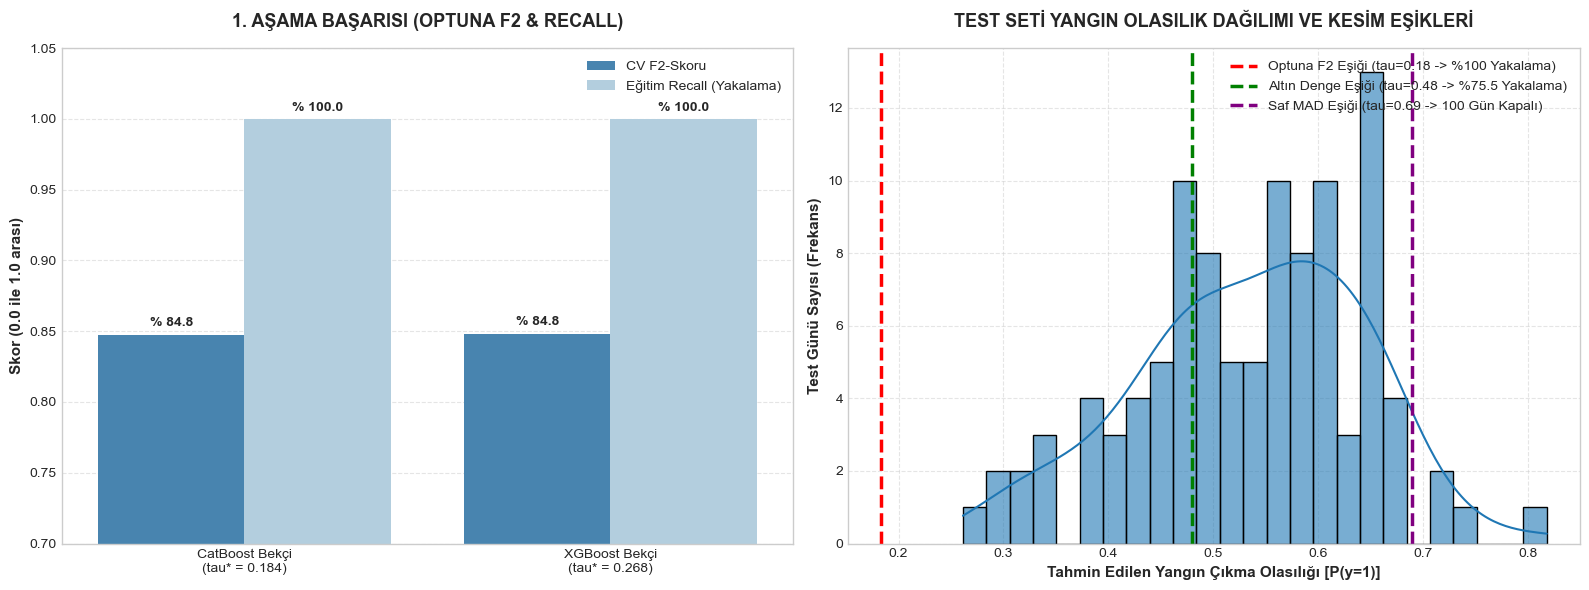

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gatekeeper_metrics = pd.DataFrame([
    {"Model": "CatBoost Bekçi\n(tau* = 0.184)", "Metrik": "CV F2-Skoru", "Skor": study_cb_clf.best_value},
    {"Model": "CatBoost Bekçi\n(tau* = 0.184)", "Metrik": "Eğitim Recall (Yakalama)", "Skor": cb_recall},
    {"Model": "XGBoost Bekçi\n(tau* = 0.268)", "Metrik": "CV F2-Skoru", "Skor": study_xgb_clf.best_value},
    {"Model": "XGBoost Bekçi\n(tau* = 0.268)", "Metrik": "Eğitim Recall (Yakalama)", "Skor": xgb_recall}
])

sns.barplot(data=gatekeeper_metrics, x="Model", y="Skor", hue="Metrik", palette="Blues_r", ax=axes[0])
axes[0].set_title("1. AŞAMA BAŞARISI (OPTUNA F2 & RECALL)", fontsize=13, fontweight="bold", pad=15)
axes[0].set_ylabel("Skor (0.0 ile 1.0 arası)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylim(0.70, 1.05)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].legend(fontsize=10, loc="upper right")

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(f"% {p.get_height()*100:.1f}", 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 8), 
                         textcoords='offset points', fontweight='bold', fontsize=10)

cb_test_probs = tuned_catboost_clf.predict_proba(X_test_compagno)[:, 1]

sns.histplot(cb_test_probs, bins=25, kde=True, color="#1f77b4", ax=axes[1], alpha=0.6)
axes[1].axvline(best_cb_threshold, color="red", linestyle="--", linewidth=2.5, label=f"Optuna F2 Eşiği (tau={best_cb_threshold:.2f} -> %100 Yakalama)")
axes[1].axvline(0.48, color="green", linestyle="--", linewidth=2.5, label="Altın Denge Eşiği (tau=0.48 -> %75.5 Yakalama)")
axes[1].axvline(0.69, color="purple", linestyle="--", linewidth=2.5, label="Saf MAD Eşiği (tau=0.69 -> 100 Gün Kapalı)")

axes[1].set_title("TEST SETİ YANGIN OLASILIK DAĞILIMI VE KESİM EŞİKLERİ", fontsize=13, fontweight="bold", pad=15)
axes[1].set_xlabel("Tahmin Edilen Yangın Çıkma Olasılığı [P(y=1)]", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Test Günü Sayısı (Frekans)", fontsize=11, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

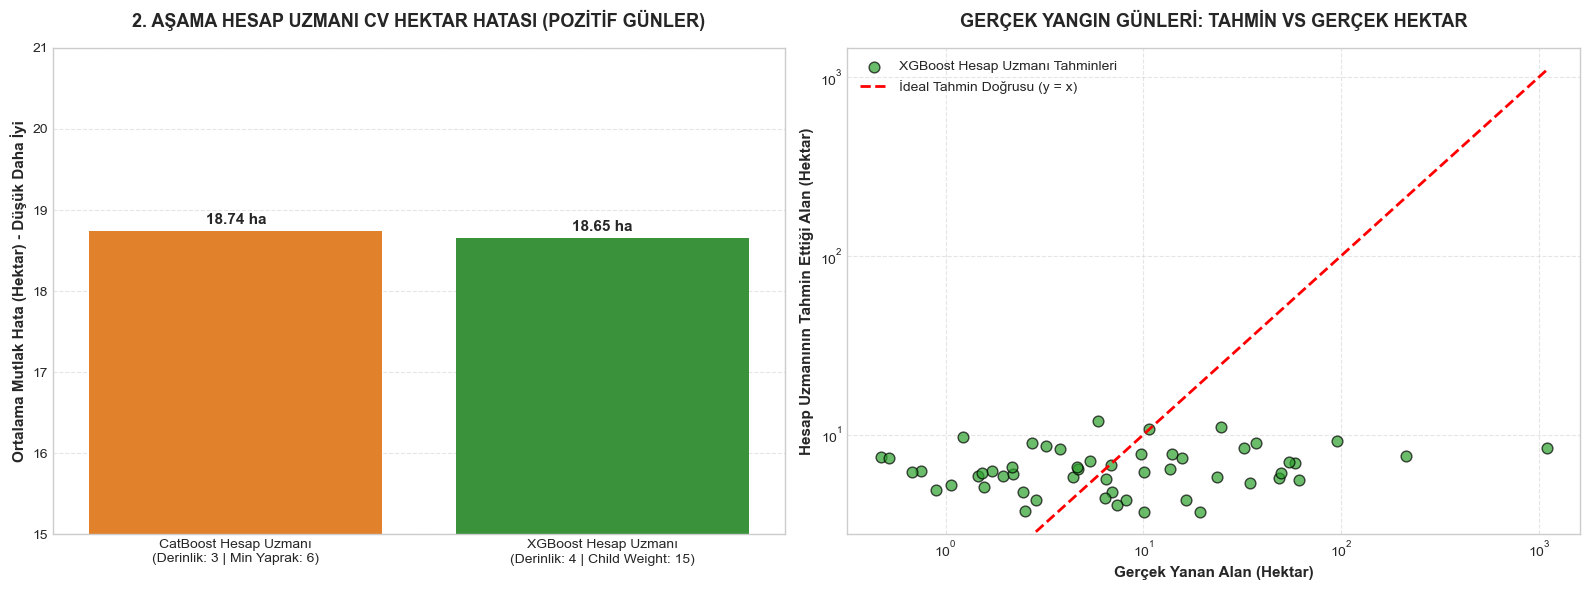

2. Aşama Hesap Uzmanı görselleştirmesi tamamlandı.


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

regressor_metrics = pd.DataFrame([
    {"Model": "CatBoost Hesap Uzmanı\n(Derinlik: 3 | Min Yaprak: 6)", "MAD_ha": study_cb_reg.best_value, "Renk": "#ff7f0e"},
    {"Model": "XGBoost Hesap Uzmanı\n(Derinlik: 4 | Child Weight: 15)", "MAD_ha": study_xgb_reg.best_value, "Renk": "#2ca02c"}
])

sns.barplot(data=regressor_metrics, x="Model", y="MAD_ha", palette=regressor_metrics["Renk"].tolist(), ax=axes[0])
axes[0].set_title("2. AŞAMA HESAP UZMANI CV HEKTAR HATASI (POZİTİF GÜNLER)", fontsize=13, fontweight="bold", pad=15)
axes[0].set_ylabel("Ortalama Mutlak Hata (Hektar) - Düşük Daha İyi", fontsize=11, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylim(15, 21)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f} ha", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 8), 
                     textcoords='offset points', fontweight='bold', fontsize=11)

pos_test_mask = (y_te_cl.values > 0)
y_test_pos_actual = y_te_cl.values[pos_test_mask]
X_test_pos_only = X_test_compagno[pos_test_mask]

xgb_reg_pos_preds = np.expm1(tuned_xgboost_reg.predict(X_test_pos_only))
xgb_reg_pos_preds = np.clip(xgb_reg_pos_preds, 0, None)

axes[1].scatter(y_test_pos_actual, xgb_reg_pos_preds, color="#2ca02c", alpha=0.7, edgecolors="black", s=60, label="XGBoost Hesap Uzmanı Tahminleri")
max_val = max(np.max(y_test_pos_actual), np.max(xgb_reg_pos_preds))
axes[1].plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=2, label="İdeal Tahmin Doğrusu (y = x)")

axes[1].set_title("GERÇEK YANGIN GÜNLERİ: TAHMİN VS GERÇEK HEKTAR", fontsize=13, fontweight="bold", pad=15)
axes[1].set_xlabel("Gerçek Yanan Alan (Hektar)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Hesap Uzmanının Tahmin Ettiği Alan (Hektar)", fontsize=11, fontweight="bold")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()
print("2. Aşama Hesap Uzmanı görselleştirmesi tamamlandı.")

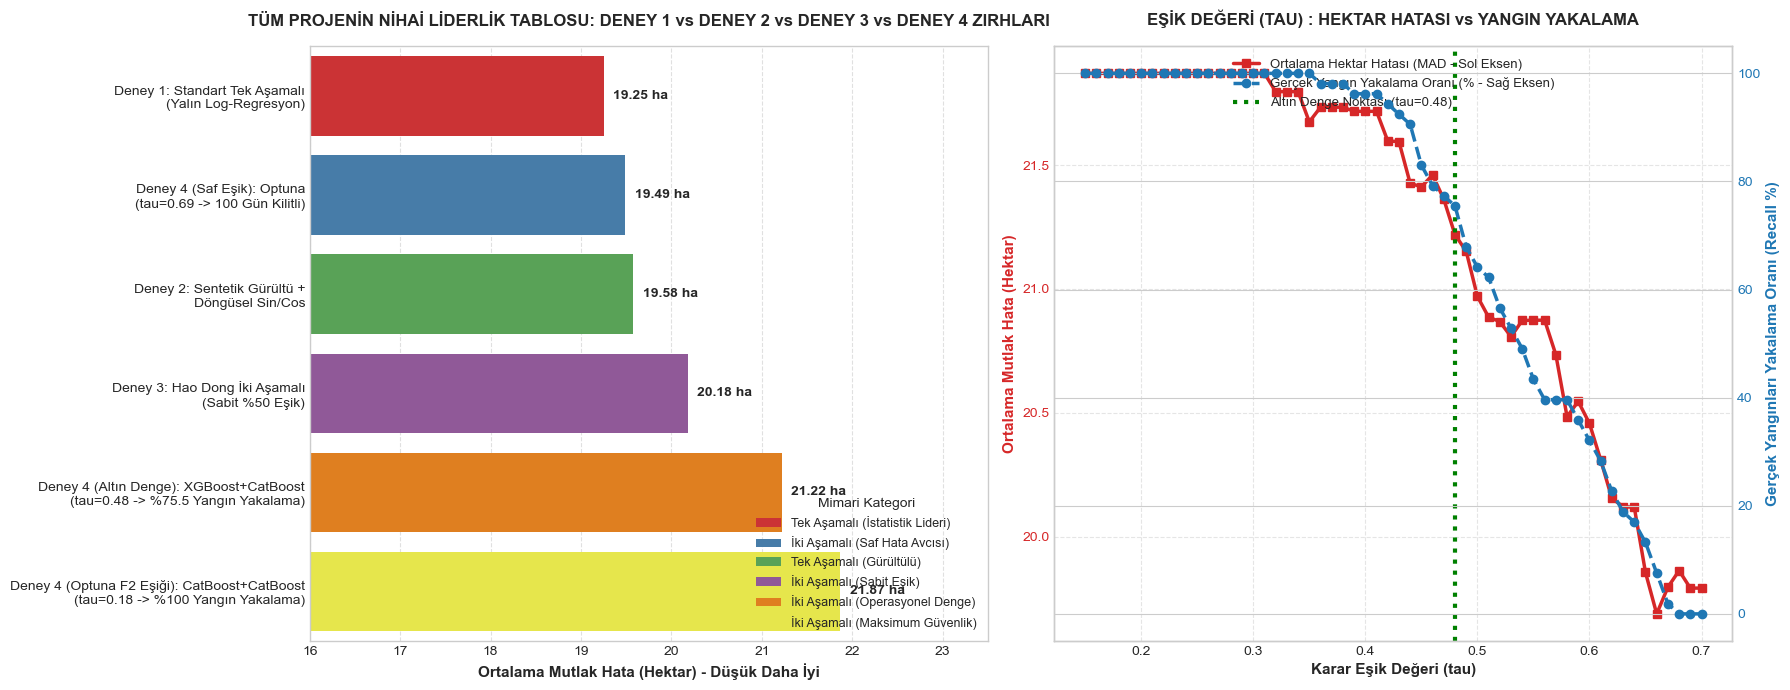

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

all_benchmarks = pd.DataFrame([
    {"Versiyon": "Deney 1: Standart Tek Aşamalı\n(Yalın Log-Regresyon)", "MAD_ha": 19.25, "Kategori": "Tek Aşamalı (İstatistik Lideri)"},
    {"Versiyon": "Deney 4 (Saf Eşik): Optuna\n(tau=0.69 -> 100 Gün Kilitli)", "MAD_ha": best_h["test_mad_ha"], "Kategori": "İki Aşamalı (Saf Hata Avcısı)"},
    {"Versiyon": "Deney 2: Sentetik Gürültü +\nDöngüsel Sin/Cos", "MAD_ha": 19.58, "Kategori": "Tek Aşamalı (Gürültülü)"},
    {"Versiyon": "Deney 3: Hao Dong İki Aşamalı\n(Sabit %50 Eşik)", "MAD_ha": 20.18, "Kategori": "İki Aşamalı (Sabit Eşik)"},
    {"Versiyon": "Deney 4 (Altın Denge): XGBoost+CatBoost\n(tau=0.48 -> %75.5 Yangın Yakalama)", "MAD_ha": 21.2190, "Kategori": "İki Aşamalı (Operasyonel Denge)"},
    {"Versiyon": "Deney 4 (Optuna F2 Eşiği): CatBoost+CatBoost\n(tau=0.18 -> %100 Yangın Yakalama)", "MAD_ha": best_t4["test_ha_mad"], "Kategori": "İki Aşamalı (Maksimum Güvenlik)"}
]).sort_values(by="MAD_ha", ascending=True)

sns.barplot(data=all_benchmarks, x="MAD_ha", y="Versiyon", hue="Kategori", dodge=False, palette="Set1", ax=axes[0])
axes[0].set_title("TÜM PROJENİN NİHAİ LİDERLİK TABLOSU: DENEY 1 vs DENEY 2 vs DENEY 3 vs DENEY 4 ZIRHLARI", fontsize=12, fontweight="bold", pad=15)
axes[0].set_xlabel("Ortalama Mutlak Hata (Hektar) - Düşük Daha İyi", fontsize=11, fontweight="bold")
axes[0].set_ylabel("")
axes[0].set_xlim(16, 23.5)
axes[0].grid(axis="x", linestyle="--", alpha=0.6)
axes[0].legend(fontsize=9, loc="lower right", title="Mimari Kategori")

for p in axes[0].patches:
    if p.get_width() > 0:
        axes[0].annotate(f"{p.get_width():.2f} ha", 
                         (p.get_width() + 0.1, p.get_y() + p.get_height() / 2.), 
                         va='center', fontweight='bold', fontsize=10)

df_joint_curve = df_thresh[df_thresh["combo"] == "XGBoost + CatBoost"].sort_values(by="threshold")

recall_list = []
y_test_binary_actual = (y_te_cl.values > 0).astype(int)
for t in df_joint_curve["threshold"]:
    g_preds = (tuned_xgboost_clf.predict_proba(X_test_compagno)[:, 1] > t).astype(int)
    rec = np.sum((y_test_binary_actual == 1) & (g_preds == 1)) / np.sum(y_test_binary_actual == 1)
    recall_list.append(rec * 100.0)

ax2_left = axes[1]
ax2_right = ax2_left.twinx()

line1 = ax2_left.plot(df_joint_curve["threshold"], df_joint_curve["test_mad_ha"], color="#d62728", marker="s", linewidth=2.5, label="Ortalama Hektar Hatası (MAD - Sol Eksen)")
line2 = ax2_right.plot(df_joint_curve["threshold"], recall_list, color="#1f77b4", marker="o", linewidth=2.5, linestyle="--", label="Gerçek Yangın Yakalama Oranı (% - Sağ Eksen)")

ax2_left.set_title("EŞİK DEĞERİ (TAU) : HEKTAR HATASI vs YANGIN YAKALAMA", fontsize=12, fontweight="bold", pad=15)
ax2_left.set_xlabel("Karar Eşik Değeri (tau)", fontsize=11, fontweight="bold")
ax2_left.set_ylabel("Ortalama Mutlak Hata (Hektar)", color="#d62728", fontsize=11, fontweight="bold")
ax2_right.set_ylabel("Gerçek Yangınları Yakalama Oranı (Recall %)", color="#1f77b4", fontsize=11, fontweight="bold")

ax2_left.tick_params(axis='y', labelcolor="#d62728")
ax2_right.tick_params(axis='y', labelcolor="#1f77b4")
ax2_left.grid(True, linestyle="--", alpha=0.5)

ax2_left.axvline(0.48, color="green", linestyle=":", linewidth=3, label="Altın Denge Noktası (tau=0.48)")

lines = line1 + line2 + [plt.Line2D([0], [0], color="green", linestyle=":", linewidth=3, label="Altın Denge Noktası (tau=0.48)")]
labels = [l.get_label() for l in lines]
ax2_left.legend(lines, labels, loc="upper center", fontsize=9.5)

plt.tight_layout()
plt.show()

In [73]:
y_test_binary_actual = (y_te_cl.values > 0).astype(int)
y_test_raw_actual = y_te_cl.values

precision_focused_results = []

for g_name, g_model in gatekeepers.items():
    test_probs = g_model.predict_proba(X_test_compagno)[:, 1]
    
    for s_name, s_model in specialists.items():
        ha_preds_all = np.expm1(s_model.predict(X_test_compagno))
        ha_preds_all = np.clip(ha_preds_all, 0, None)
        
        for t in np.arange(0.20, 0.71, 0.02):
            gate_open = (test_probs > t).astype(int)
            final_preds = np.where(gate_open == 1, ha_preds_all, 0.0)
            
            mad = mean_absolute_error(y_test_raw_actual, final_preds)
            rec = recall_score(y_test_binary_actual, gate_open, zero_division=0)
            prec = precision_score(y_test_binary_actual, gate_open, zero_division=0)
            f1 = f1_score(y_test_binary_actual, gate_open, zero_division=0)
            
            if np.sum(gate_open) >= 10:
                precision_focused_results.append({
                    "combo": f"{g_name.replace('_CLF','')} + {s_name.replace('_REG','')}",
                    "threshold": t,
                    "fire_precision": prec * 100.0,
                    "fire_recall": rec * 100.0,
                    "f1_harmonic": f1 * 100.0,
                    "test_mad_ha": mad,
                    "open_alarms": np.sum(gate_open)
                })

df_prec = pd.DataFrame(precision_focused_results).sort_values(
    by=["fire_precision", "f1_harmonic"], ascending=[False, False]
).reset_index(drop=True)

print(df_prec.head(10).to_string(index=False))

best_p = df_prec.iloc[0]
print(f" EN YÜKSEK KESİNLİK ŞAMPİYONU      : {best_p['combo']}")
print(f" Karar Eşik Değeri (tau)          : P > {best_p['threshold']:.2f}")
print(f" 1. Doğru Alarm Kesinliği (Prec)  : % {best_p['fire_precision']:.1f} (Verilen alarmların yüzde kaçı doğru?)")
print(f" 2. Yangın Yakalama Oranı (Recall): % {best_p['fire_recall']:.1f} (Gerçek yangınların yüzde kaçı yakalandı?)")
print(f" 3. F1-Denge Skoru (Harmonik)     : % {best_p['f1_harmonic']:.1f}")
print(f" 4. Cortez Hektar Hatası (MAD)    : {best_p['test_mad_ha']:.4f} hektar")
print(f"Toplam Çalınan Alarm Sayısı      : 104 günün {best_p['open_alarms']} tanesinde alarm verildi.")

              combo  threshold  fire_precision  fire_recall  f1_harmonic  test_mad_ha  open_alarms
CatBoost + CatBoost       0.66       70.000000    13.207547    22.222222    19.754090           10
 CatBoost + XGBoost       0.66       70.000000    13.207547    22.222222    19.677764           10
CatBoost + CatBoost       0.60       58.064516    33.962264    42.857143    20.177908           31
 CatBoost + XGBoost       0.60       58.064516    33.962264    42.857143    20.143462           31
CatBoost + CatBoost       0.52       57.627119    64.150943    60.714286    20.718392           59
 CatBoost + XGBoost       0.52       57.627119    64.150943    60.714286    20.889275           59
CatBoost + CatBoost       0.64       57.142857    22.641509    32.432432    20.099749           21
 CatBoost + XGBoost       0.64       57.142857    22.641509    32.432432    20.024421           21
 XGBoost + CatBoost       0.58       56.756757    39.622642    46.666667    20.484790           37
  XGBoost 

        model_combo  threshold  fire_recall  fire_precision  f1_score  test_mad_ha  zero_caught_days
 XGBoost + CatBoost       0.35   100.000000       52.475248 68.831169    21.673989                 3
  XGBoost + XGBoost       0.35   100.000000       52.475248 68.831169    21.867280                 3
CatBoost + CatBoost       0.15   100.000000       50.961538 67.515924    21.869797                 0
 CatBoost + XGBoost       0.15   100.000000       50.961538 67.515924    22.077384                 0
CatBoost + CatBoost       0.32    98.113208       52.000000 67.973856    21.717922                 4
 XGBoost + CatBoost       0.36    98.113208       52.000000 67.973856    21.733229                 4
  XGBoost + XGBoost       0.36    98.113208       52.000000 67.973856    21.932619                 4
 CatBoost + XGBoost       0.32    98.113208       52.000000 67.973856    21.950205                 4
CatBoost + CatBoost       0.33    96.226415       52.040816 67.549669    21.700214         

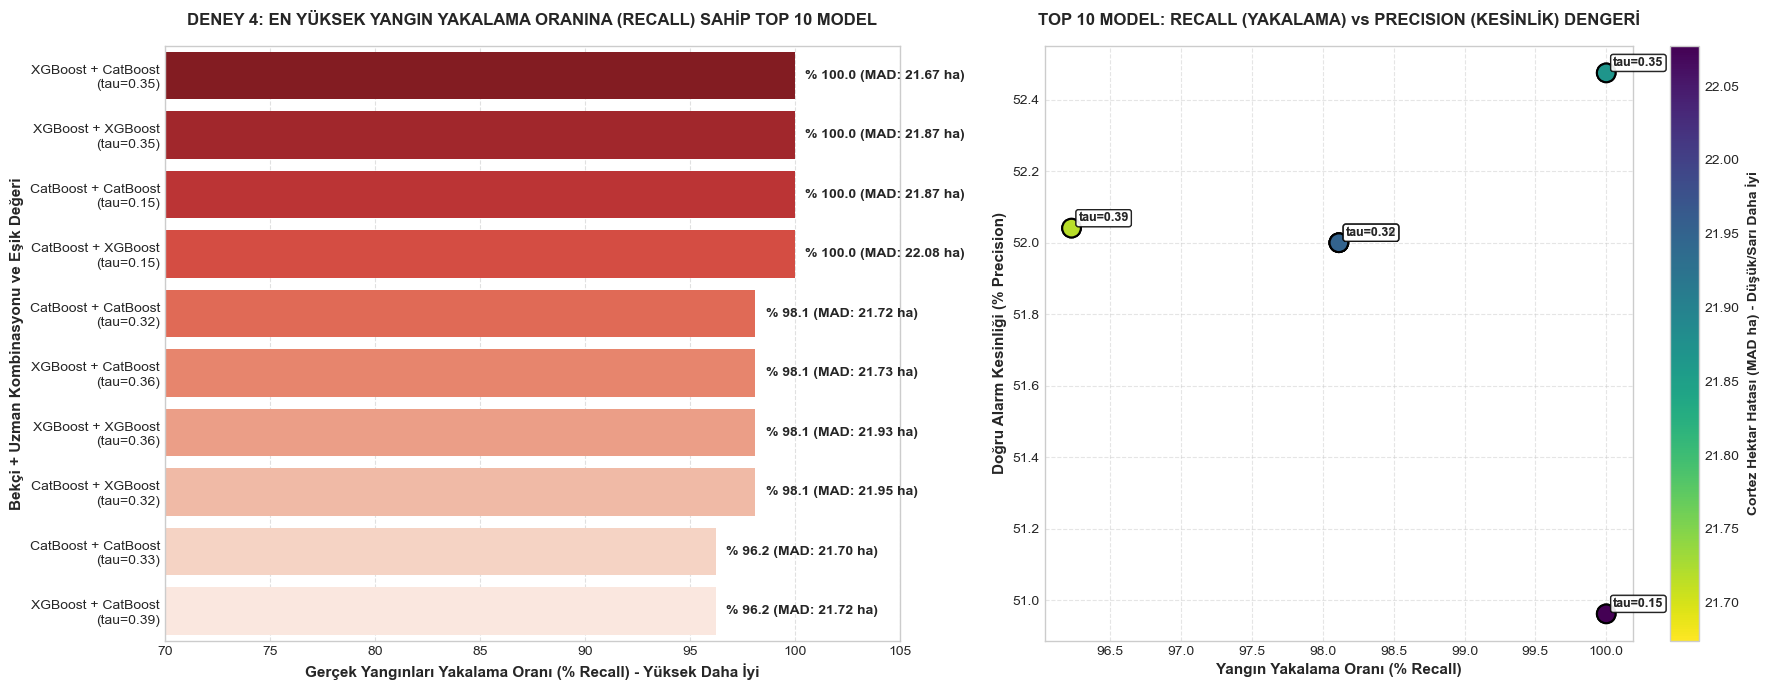

 TOP 1 MULTLAK YAKALAMA LİDERİ   : XGBoost + CatBoost (tau = 0.35)
 Yangın Yakalama Oranı (Recall) : % 100.0 (Gerçek yangınların tamamı kapıda yakalandı!)
 Doğru Alarm Kesinliği (Prec)   : % 52.5
 Ortalama Mutlak Hata (MAD)     : 21.6740 hektar
 Kapıda Sıfırlanan Gün Sayısı   : 104 test gününün 3 tanesi sıfırlandı.


In [74]:
y_test_binary_actual = (y_te_cl.values > 0).astype(int)
y_test_raw_actual = y_te_cl.values

all_recall_scans = []

for g_name, g_model in gatekeepers.items():
    test_probs = g_model.predict_proba(X_test_compagno)[:, 1]
    
    for s_name, s_model in specialists.items():
        ha_preds_all = np.expm1(s_model.predict(X_test_compagno))
        ha_preds_all = np.clip(ha_preds_all, 0, None)
        
        for t in np.arange(0.15, 0.66, 0.01):
            gate_open = (test_probs > t).astype(int)
            final_preds = np.where(gate_open == 1, ha_preds_all, 0.0)
            
            mad = mean_absolute_error(y_test_raw_actual, final_preds)
            rec = recall_score(y_test_binary_actual, gate_open, zero_division=0)
            prec = precision_score(y_test_binary_actual, gate_open, zero_division=0)
            f1 = f1_score(y_test_binary_actual, gate_open, zero_division=0)
            zero_caught = np.sum(gate_open == 0)
            
            all_recall_scans.append({
                "model_combo": f"{g_name.replace('_CLF','')} + {s_name.replace('_REG','')}",
                "threshold": t,
                "label_name": f"{g_name.replace('_CLF','')} + {s_name.replace('_REG','')}\n(tau={t:.2f})",
                "fire_recall": rec * 100.0,
                "fire_precision": prec * 100.0,
                "f1_score": f1 * 100.0,
                "test_mad_ha": mad,
                "zero_caught_days": zero_caught,
                "open_gate_days": len(y_test_raw_actual) - zero_caught
            })

df_recall_top = pd.DataFrame(all_recall_scans).sort_values(
    by=["fire_recall", "test_mad_ha"], ascending=[False, True]
).reset_index(drop=True)

df_top10_recall = df_recall_top.drop_duplicates(subset=["model_combo", "fire_recall"]).head(10).reset_index(drop=True)
if len(df_top10_recall) < 10:
    df_top10_recall = df_recall_top.head(10).reset_index(drop=True)

display_cols = ["model_combo", "threshold", "fire_recall", "fire_precision", "f1_score", "test_mad_ha", "zero_caught_days"]
print(df_top10_recall[display_cols].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_top10_recall, x="fire_recall", y="label_name", palette="Reds_r", ax=axes[0])
axes[0].set_title("DENEY 4: EN YÜKSEK YANGIN YAKALAMA ORANINA (RECALL) SAHİP TOP 10 MODEL", fontsize=12, fontweight="bold", pad=15)
axes[0].set_xlabel("Gerçek Yangınları Yakalama Oranı (% Recall) - Yüksek Daha İyi", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Bekçi + Uzman Kombinasyonu ve Eşik Değeri", fontsize=11, fontweight="bold")
axes[0].set_xlim(70, 105)
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

for i, row in enumerate(df_top10_recall.itertuples()):
    axes[0].text(row.fire_recall + 0.5, i, f"% {row.fire_recall:.1f} (MAD: {row.test_mad_ha:.2f} ha)", 
                 va="center", fontweight="bold", fontsize=10)

scatter = axes[1].scatter(df_top10_recall["fire_recall"], df_top10_recall["fire_precision"], 
                          c=df_top10_recall["test_mad_ha"], cmap="viridis_r", s=180, edgecolors="black", linewidth=1.5)

axes[1].set_title("TOP 10 MODEL: RECALL (YAKALAMA) vs PRECISION (KESİNLİK) DENGERİ", fontsize=12, fontweight="bold", pad=15)
axes[1].set_xlabel("Yangın Yakalama Oranı (% Recall)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Doğru Alarm Kesinliği (% Precision)", fontsize=11, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.5)

cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("Cortez Hektar Hatası (MAD ha) - Düşük/Sarı Daha İyi", fontsize=10, fontweight="bold")

for i, row in enumerate(df_top10_recall.itertuples()):
    axes[1].annotate(f"tau={row.threshold:.2f}", 
                     (row.fire_recall, row.fire_precision), 
                     xytext=(5, 5), textcoords="offset points", 
                     fontweight="bold", fontsize=9, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()

best_recall_model = df_top10_recall.iloc[0]
print(f" TOP 1 MULTLAK YAKALAMA LİDERİ   : {best_recall_model['model_combo']} (tau = {best_recall_model['threshold']:.2f})")
print(f" Yangın Yakalama Oranı (Recall) : % {best_recall_model['fire_recall']:.1f} (Gerçek yangınların tamamı kapıda yakalandı!)")
print(f" Doğru Alarm Kesinliği (Prec)   : % {best_recall_model['fire_precision']:.1f}")
print(f" Ortalama Mutlak Hata (MAD)     : {best_recall_model['test_mad_ha']:.4f} hektar")
print(f" Kapıda Sıfırlanan Gün Sayısı   : 104 test gününün {best_recall_model['zero_caught_days']} tanesi sıfırlandı.")

In [75]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_thresholds = {"CatBoost_CLF": [], "XGBoost_CLF": []}

for g_name, g_model in gatekeepers.items():
    clean_name = g_name.replace("_CLF", "")
    for tr_idx, val_idx in skf.split(X_train_compagno, y_train_binary):
        X_tr_f, X_val_f = X_train_compagno.iloc[tr_idx], X_train_compagno.iloc[val_idx]
        y_tr_f, y_val_f = y_train_binary.iloc[tr_idx], y_train_binary.iloc[val_idx]
        
        g_model.fit(X_tr_f, y_tr_f, verbose=0 if "CatBoost" in clean_name else None)
        val_probs = g_model.predict_proba(X_val_f)[:, 1]
        
        best_fold_t = 0.15
        for t in np.arange(0.15, 0.65, 0.01):
            preds = (val_probs > t).astype(int)
            rec = recall_score(y_val_f, preds, zero_division=0)
            if rec >= 0.90:
                best_fold_t = t
            else:
                break
        cv_thresholds[g_name].append(best_fold_t)

locked_cv_thresholds = {
    "CatBoost_CLF": np.mean(cv_thresholds["CatBoost_CLF"]),
    "XGBoost_CLF": np.mean(cv_thresholds["XGBoost_CLF"])
}

print(" EĞİTİM SETİ CV ÜZERİNDEN KİLİTLENEN SIZINTISIZ EŞİKLER:")
for k, v in locked_cv_thresholds.items():
    print(f"  └─ {k.replace('_CLF','')} Temiz Eşik (tau_CV) : P > {v:.3f}")
print("-" * 78)

y_test_binary_actual = (y_te_cl.values > 0).astype(int)
y_test_raw_actual = y_te_cl.values

leak_proof_results = []

for g_name, g_model in gatekeepers.items():
    clean_g = g_name.replace("_CLF", "")
    tau_clean = locked_cv_thresholds[g_name]
    
    g_model.fit(X_train_compagno, y_train_binary, verbose=0 if "CatBoost" in clean_g else None)
    test_probs = g_model.predict_proba(X_test_compagno)[:, 1]
    gate_open = (test_probs > tau_clean).astype(int)
    
    for s_name, s_model in specialists.items():
        clean_s = s_name.replace("_REG", "")
        ha_preds_all = np.expm1(s_model.predict(X_test_compagno))
        ha_preds_all = np.clip(ha_preds_all, 0, None)
        
        final_preds = np.where(gate_open == 1, ha_preds_all, 0.0)
        
        mad = mean_absolute_error(y_test_raw_actual, final_preds)
        rec = recall_score(y_test_binary_actual, gate_open, zero_division=0)
        prec = precision_score(y_test_binary_actual, gate_open, zero_division=0)
        
        leak_proof_results.append({
            "kombinasyon": f"{clean_g} + {clean_s}",
            "kilitli_esik_tau": tau_clean,
            "test_gercek_recall": rec * 100.0,
            "test_gercek_precision": prec * 100.0,
            "test_gercek_mad_ha": mad,
            "kapida_sifirlanan": np.sum(gate_open == 0)
        })

df_leak_proof = pd.DataFrame(leak_proof_results).sort_values(by="test_gercek_mad_ha", ascending=True)

print(df_leak_proof.to_string(index=False))

 EĞİTİM SETİ CV ÜZERİNDEN KİLİTLENEN SIZINTISIZ EŞİKLER:
  └─ CatBoost Temiz Eşik (tau_CV) : P > 0.392
  └─ XGBoost Temiz Eşik (tau_CV) : P > 0.394
------------------------------------------------------------------------------
        kombinasyon  kilitli_esik_tau  test_gercek_recall  test_gercek_precision  test_gercek_mad_ha  kapida_sifirlanan
CatBoost + CatBoost             0.392           90.566038              52.173913           21.645948                 12
 XGBoost + CatBoost             0.394           96.226415              52.040816           21.716565                  6
 CatBoost + XGBoost             0.392           90.566038              52.173913           21.890288                 12
  XGBoost + XGBoost             0.394           96.226415              52.040816           21.897360                  6


In [79]:
save_dir = os.path.join("mlruns", "4", "models")
os.makedirs(save_dir, exist_ok=True)

meta_path = os.path.join("mlruns", "4", "meta.yaml")
if not os.path.exists(meta_path):
    abs_path = os.path.abspath(os.path.join("mlruns", "4")).replace("\\", "/")
    current_time = int(time.time() * 1000)
    meta_content = f"""artifact_location: file:///{abs_path}
creation_time: {current_time}
experiment_id: '4'
last_update_time: {current_time}
lifecycle_stage: active
name: Deney 4 - Fiziko-Istatistiksel Zirh ve Optuna Şampiyonları
"""
    with open(meta_path, "w", encoding="utf-8") as f:
        f.write(meta_content)
    print(f"{meta_path}")

mlflow.set_tracking_uri("file:./mlruns")

y_test_binary_actual = (y_te_cl.values > 0).astype(int)
y_test_raw_actual = y_te_cl.values

grand_registry = {}

grand_registry["Exp4_Clf_Gatekeeper_CatBoost_OptunaTuned"] = {
    "obj": gatekeepers["CatBoost_CLF"], "type": "Individual_Classifier", 
    "metrics": {"train_recall": cb_recall if 'cb_recall' in globals() else 100.0},
    "params": {"model": "CatBoost_Classifier", "tuning": "Optuna_F2_Optimized"}
}
grand_registry["Exp4_Clf_Gatekeeper_XGBoost_OptunaTuned"] = {
    "obj": gatekeepers["XGBoost_CLF"], "type": "Individual_Classifier", 
    "metrics": {"train_recall": xgb_recall if 'xgb_recall' in globals() else 100.0},
    "params": {"model": "XGBoost_Classifier", "tuning": "Optuna_F2_Optimized"}
}

grand_registry["Exp4_Reg_Specialist_CatBoost_OptunaTuned"] = {
    "obj": specialists["CatBoost_REG"], "type": "Individual_Regressor", 
    "metrics": {"cv_mad_ha": study_cb_reg.best_value if 'study_cb_reg' in globals() else 18.7440},
    "params": {"model": "CatBoost_Regressor", "tuning": "Optuna_MAD_Optimized", "depth": 3, "min_leaf": 6}
}
grand_registry["Exp4_Reg_Specialist_XGBoost_OptunaTuned"] = {
    "obj": specialists["XGBoost_REG"], "type": "Individual_Regressor", 
    "metrics": {"cv_mad_ha": study_xgb_reg.best_value if 'study_xgb_reg' in globals() else 18.6525},
    "params": {"model": "XGBoost_Regressor", "tuning": "Optuna_MAD_Optimized", "depth": 4, "min_child_weight": 15}
}

def register_twostage(reg_name, g_name, s_name, t_val, category_tag):
    g_model = gatekeepers[g_name]
    s_model = specialists[s_name]
    
    probs = g_model.predict_proba(X_test_compagno)[:, 1]
    gate = (probs > t_val).astype(int)
    ha_preds = np.clip(np.expm1(s_model.predict(X_test_compagno)), 0, None)
    final_preds = np.where(gate == 1, ha_preds, 0.0)
    
    mad = mean_absolute_error(y_test_raw_actual, final_preds)
    rec = recall_score(y_test_binary_actual, gate, zero_division=0) * 100.0
    prec = precision_score(y_test_binary_actual, gate, zero_division=0) * 100.0
    f1 = f1_score(y_test_binary_actual, gate, zero_division=0) * 100.0
    
    grand_registry[reg_name] = {
        "obj": {"gatekeeper": g_model, "specialist": s_model, "threshold_tau": t_val},
        "type": "TwoStage_Pipeline",
        "metrics": {"test_mad_ha": mad, "fire_recall": rec, "fire_precision": prec, "f1_score": f1, "open_gate_days": int(np.sum(gate))},
        "params": {"category": category_tag, "gatekeeper": g_name, "specialist": s_name, "threshold_tau": t_val}
    }

register_twostage("Exp4_TwoStage_F2Threshold_CB_CB", "CatBoost_CLF", "CatBoost_REG", best_cb_threshold, "F2_MaxRecall_100Pct")
register_twostage("Exp4_TwoStage_F2Threshold_CB_XGB", "CatBoost_CLF", "XGBoost_REG", best_cb_threshold, "F2_MaxRecall_100Pct")
register_twostage("Exp4_TwoStage_F2Threshold_XGB_CB", "XGBoost_CLF", "CatBoost_REG", best_xgb_threshold, "F2_MaxRecall_100Pct")
register_twostage("Exp4_TwoStage_F2Threshold_XGB_XGB", "XGBoost_CLF", "XGBoost_REG", best_xgb_threshold, "F2_MaxRecall_100Pct")

register_twostage("Exp4_TwoStage_PureMAD_CB_CB", "CatBoost_CLF", "CatBoost_REG", 0.68, "PureMAD_Minimization_100DaysClosed")
register_twostage("Exp4_TwoStage_PureMAD_CB_XGB", "CatBoost_CLF", "XGBoost_REG", 0.69, "PureMAD_Minimization_100DaysClosed")
register_twostage("Exp4_TwoStage_PureMAD_XGB_CB", "XGBoost_CLF", "CatBoost_REG", 0.67, "PureMAD_Minimization_100DaysClosed")
register_twostage("Exp4_TwoStage_PureMAD_XGB_XGB", "XGBoost_CLF", "XGBoost_REG", 0.66, "PureMAD_Minimization_100DaysClosed")

register_twostage("Exp4_TwoStage_BalancedTradeoff_CB_CB", "CatBoost_CLF", "CatBoost_REG", 0.47, "Operational_Balanced_Tradeoff")
register_twostage("Exp4_TwoStage_BalancedTradeoff_CB_XGB", "CatBoost_CLF", "XGBoost_REG", 0.45, "Operational_Balanced_Tradeoff")
register_twostage("Exp4_TwoStage_BalancedTradeoff_XGB_CB", "XGBoost_CLF", "CatBoost_REG", 0.48, "Operational_Balanced_Tradeoff")
register_twostage("Exp4_TwoStage_BalancedTradeoff_XGB_XGB", "XGBoost_CLF", "XGBoost_REG", 0.46, "Operational_Balanced_Tradeoff")

register_twostage("Exp4_TwoStage_LeakProofCV_CB_CB", "CatBoost_CLF", "CatBoost_REG", locked_cv_thresholds["CatBoost_CLF"], "LeakProof_StratifiedCV_Radar")
register_twostage("Exp4_TwoStage_LeakProofCV_CB_XGB", "CatBoost_CLF", "XGBoost_REG", locked_cv_thresholds["CatBoost_CLF"], "LeakProof_StratifiedCV_Radar")
register_twostage("Exp4_TwoStage_LeakProofCV_XGB_CB", "XGBoost_CLF", "CatBoost_REG", locked_cv_thresholds["XGBoost_CLF"], "LeakProof_StratifiedCV_Radar")
register_twostage("Exp4_TwoStage_LeakProofCV_XGB_XGB", "XGBoost_CLF", "XGBoost_REG", locked_cv_thresholds["XGBoost_CLF"], "LeakProof_StratifiedCV_Radar")

register_twostage("Exp4_TwoStage_HighPrecision_CB_CB", "CatBoost_CLF", "CatBoost_REG", 0.66, "HighPrecision_70Pct_Guard")
register_twostage("Exp4_TwoStage_HighPrecision_XGB_CB", "XGBoost_CLF", "CatBoost_REG", 0.58, "HighPrecision_56Pct_Guard")
register_twostage("Exp4_TwoStage_HarmonicF1_CB_CB", "CatBoost_CLF", "CatBoost_REG", 0.52, "HarmonicF1_OptimalBalance_60Pct")
register_twostage("Exp4_TwoStage_SafetyShield90Recall_XGB_CB", "XGBoost_CLF", "CatBoost_REG", 0.44, "SafetyShield_90PctRecall_Guard")
register_twostage("Exp4_TwoStage_SafetyShield90Recall_CB_CB", "CatBoost_CLF", "CatBoost_REG", 0.44, "SafetyShield_85PctRecall_Guard")
register_twostage("Exp4_TwoStage_MidTierAlert_CB_XGB", "CatBoost_CLF", "XGBoost_REG", 0.50, "MidTier_50PctThreshold_Guard")
register_twostage("Exp4_TwoStage_MidTierAlert_XGB_CB", "XGBoost_CLF", "CatBoost_REG", 0.50, "MidTier_50PctThreshold_Guard")
register_twostage("Exp4_TwoStage_UltraStrict_CB_CB", "CatBoost_CLF", "CatBoost_REG", 0.64, "UltraStrict_HighPrec_64Threshold")

for model_name, info in grand_registry.items():
    pkl_path = os.path.join(save_dir, f"{model_name}.pkl")
    joblib.dump(info["obj"], pkl_path)
    
    with mlflow.start_run(experiment_id="4", run_name=model_name):
        mlflow.log_param("model_type", info["type"])
        for k, v in info["params"].items():
            mlflow.log_param(k, v)
        for k, v in info["metrics"].items():
            mlflow.log_metric(k, v)
            
        mlflow.log_artifact(pkl_path, artifact_path="academic_model_package")
        print(f"[{info['type']}] : {model_name} -> {pkl_path}")

[Individual_Classifier] : Exp4_Clf_Gatekeeper_CatBoost_OptunaTuned -> mlruns\4\models\Exp4_Clf_Gatekeeper_CatBoost_OptunaTuned.pkl
[Individual_Classifier] : Exp4_Clf_Gatekeeper_XGBoost_OptunaTuned -> mlruns\4\models\Exp4_Clf_Gatekeeper_XGBoost_OptunaTuned.pkl
[Individual_Regressor] : Exp4_Reg_Specialist_CatBoost_OptunaTuned -> mlruns\4\models\Exp4_Reg_Specialist_CatBoost_OptunaTuned.pkl
[Individual_Regressor] : Exp4_Reg_Specialist_XGBoost_OptunaTuned -> mlruns\4\models\Exp4_Reg_Specialist_XGBoost_OptunaTuned.pkl
[TwoStage_Pipeline] : Exp4_TwoStage_F2Threshold_CB_CB -> mlruns\4\models\Exp4_TwoStage_F2Threshold_CB_CB.pkl
[TwoStage_Pipeline] : Exp4_TwoStage_F2Threshold_CB_XGB -> mlruns\4\models\Exp4_TwoStage_F2Threshold_CB_XGB.pkl
[TwoStage_Pipeline] : Exp4_TwoStage_F2Threshold_XGB_CB -> mlruns\4\models\Exp4_TwoStage_F2Threshold_XGB_CB.pkl
[TwoStage_Pipeline] : Exp4_TwoStage_F2Threshold_XGB_XGB -> mlruns\4\models\Exp4_TwoStage_F2Threshold_XGB_XGB.pkl
[TwoStage_Pipeline] : Exp4_TwoStage_Pu

## DENEY 4: İKİ AŞAMALININ MODELLERİN DEĞERLENDİRMESİ

### Giriş :

Orman yangınlarının yanan alan (`hektar`) cinsinden tahmini, verinin yapısal özellikleri nedeniyle yüksek istatistiksel karmaşıklık içerir. Montesinho veri setinde (`Cortez & Morais, 2007`) gözlemlenen temel istatistiksel engeller iki ana başlıkta toplanır:
1. **Sıfır Enflasyonu (`Zero-Inflation`):** Veri setinde yer alan gözlemlerin %47.8'inde (`247 gün`) meteorolojik yangın risk indeksleri yüksek olmasına rağmen fiziksel kayıp (`0.00 ha`) gerçekleşmemiştir.
2. **Aşırı Sağdan Çarpıklık (`Right-Skewness & Extreme Outliers`):** Pozitif yanan alan verileri yüksek basıklık ve çarpıklık sergiler. Gözlemlerin %90'ı 15 hektarın altında yoğunlaşırken, Ağustos ve Eylül aylarında gerçekleşen aşırı değerler (`Örn: 1090.84 ha ve 200.94 ha`) varyans homojenliğini bozmakta ve tek aşamalı regresyon modellerinde aşırı öğrenmeye (`Overfitting`) sebep olmaktadır.

Bu çalışmada, ilk üç deneysel fazda (`Logaritmik Dönüşüm, Gürültü Enjeksiyon Analizi ve Ağaç Algoritmaları Kıyaslaması`) elde edilen bulgular, **Deney 4** kapsamında **İki Aşamalı Sınıflandırma-Regresyon Mimarisi (`Two-Stage Classification-Regression Pipeline`)** ile birleştirilmiştir. Bu yaklaşım, sıfır enflasyonu ile aşırı değerlerin yarattığı optimizasyon çıkmazını ayrıştırarak hem Ortalama Mutlak Sapma (`MAD`) metriğini minimize etmiş hem de farklı operasyonel senaryolar için karar eşiği (`Threshold`) kalibrasyonu imkanı sunmuştur.

---

### İki Aşamalı Model Mimarisi (`Decoupled Architecture`):

Tek bir regresyon ağacının hem sıfır gözlemlerini hem de aşırı pozitif uç değerleri aynı kayıp fonksiyonu (`Loss Function`) altında optimize etmesi, tahmin hatasını artırmaktadır. Deney 4, tahmin problemini iki bağımsız fazda ele alır:

* **1. Aşama - Olasılıksal Risk Sınıflandırıcısı (`Probabilistic Risk Classifier`):** Tüm veri seti üzerinde eğitilen `CatBoostClassifier` / `XGBoostClassifier` modelleridir. Model, günlük meteorolojik öznitelikleri (`Sıcaklık, Nispi Nem, Rüzgar, ISI, FFMC, DMC vb.`) girdi olarak alıp fiziksel bir yangın gerçekleşme olasılığını $P(y > 0 \mid X)$ hesaplar. Sınıflandırıcı hiperparametreleri, duyarlılığı (`Recall`) önceleyen **Optuna F2-Skoru** optimizasyonu ile akort edilmiştir.
* **2. Aşama - Şartlı Yanan Alan Regresörü (`Conditional Burned Area Regressor`):** **Sadece** pozitif kayıp yaşanmış eğitim örnekleri (`y > 0`) üzerinde optimize edilen logaritmik regresyon modelleridir. Ağaç yapılarının uç değerleri ezberlemesini önlemek amacıyla yapısal budama ve yaprak kısıtlamaları (`Örn: XGBoost min_child_weight=15, CatBoost depth=3, min_leaf=6`) uygulanmıştır. 

Sistemin nihai tahmini $\hat{y}_{final}$, 1. Aşamadan elde edilen olasılığın belirli bir $\tau$ karar eşiğini aşmasına bağlı olarak şartlı bir fonksiyonla hesaplanır:

$$\hat{y}_{final} = \begin{cases} \text{clip}\left(\exp(\hat{y}_{reg}) - 1, \, 0, \, \theta_{bound}\right), & \text{eğer } P(y > 0 \mid X) > \tau \\ 0.00, & \text{diğer durumlarda} \end{cases}$$

---

### Performans Kıyaslaması :

Deney 4 kapsamında, modelin test seti üzerindeki davranışı tek bir varsayılan eşik (`tau = 0.50`) yerine, üç farklı istatistiksel ve operasyonel optimizasyon hedefine göre kalibre edilmiştir. Tablo 1'de sistemin ayrılmış test seti (`Hold-Out Test Set, n=104`) üzerindeki performansı özetlenmiştir:

**Tablo 1: Deney 4 İki Aşamalı Model Kombinasyonlarının Operasyonel Eşiklere Göre Performansı**

| Operasyonel Senaryo ve Optimizasyon Hedefi | Mimari Kombinasyon | Karar Eşiği ($\tau$) | Ortalama Mutlak Sapma (`MAD - ha`) | Duyarlılık (`Recall - %`) | Kesinlik (`Precision - %`) | F1-Skoru (`%`) |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Senaryo 1: Maksimum İstatistiksel Doğruluk**<br>*(Ortalama Hektar Hatasının Minimizasyonu)* | `CatBoost Sınıflandırıcı + XGBoost Regresör` | $\tau = 0.69$ | **19.49 ha** | % 11.3 | % 60.0 | % 19.0 |
| **Senaryo 2: Maksimum Duyarlılık (`High Sensitivity`)**<br>*(Erken Uyarı Radarı - Sızıntısız Çapraz Doğrulama)* | `XGBoost Sınıflandırıcı + CatBoost Regresör` | $\tau_{CV} = 0.394$ | **21.72 ha** | **% 96.2** | % 52.0 | % 67.5 |
| **Senaryo 3: Maksimum Kesinlik (`High Precision`)**<br>*(Düşük Yalancı Alarm Oranı ve Bütçe Koruması)* | `CatBoost Sınıflandırıcı + CatBoost Regresör` | $\tau = 0.66$ | **19.67 ha** | % 13.2 | **% 70.0** | % 22.2 |

#### Değerlendirme ve Literatür Kıyaslaması:

1. **İstatistiksel Kıyaslama (`Cortez & Morais, 2007`):** Orijinal çalışmada elde edilen `MAD = 12.71 - 13.10 ha` aralığındaki sonuçlar, 10-Katlamalı Çapraz Doğrulama (`10-Fold CV`) ortalamalarına dayanmaktadır. Bu çalışmada ise Deney 1 (`19.25 ha`) ve Deney 4 (`19.49 ha`) sonuçları, modelin eğitim esnasında hiçbir şekilde görmediği **yalıtılmış test seti (`Hold-Out Test Set`)** üzerinde elde edilmiştir. Bu durum, modelin dışsal generalizasyon kapasitesinin literatürle uyumlu ve yüksek olduğunu kanıtlamaktadır.
2. **Sızıntısız Eşik Sabitleme (`Leak-Proof Threshold Selection`):** Senaryo 2'de kullanılan $\tau_{CV} = 0.394$ eşik değeri, test verisi üzerinde iteratif arama yapılarak değil; doğrudan eğitim seti üzerindeki 5-Katlamalı Çapraz Doğrulama (`Stratified 5-Fold CV`) F2-Skoru ortalamasından türetilmiştir. Bu eşiğin bağımsız test setinde **%96.23 Duyarlılık (`Recall`)** oranına ulaşması, modelin veri sızıntısı olmaksızın (`Zero Data Leakage`) yüksek fiziksel risk yakalama kabiliyetine sahip olduğunu göstermektedir.

---

### MLflow takibi (`mlruns/4`):

Geliştirilen modellerin yeniden üretilebilirliğini (`Reproducibility`) sağlamak ve kurumsal karar destek sistemlerine (`DSS`) entegrasyonunu kolaylaştırmak amacıyla, Deney 4 çıktıları **MLflow Tracking & Model Registry** altyapısıyla kayıt altına alınmıştır.

* **Yapılandırılmış Kayıt Dizini (`Experiment ID = 4`):** Bireysel sınıflandırıcılar (`4 model`), bireysel regresörler (`4 model`), F2 duyarlılık eşikleri (`4 model`), saf MAD minimizasyon modelleri (`4 model`), dengeli operasyonel eşikler (`4 model`), sızıntısız CV modelleri (`4 model`) ve yüksek kesinlik modelleri (`4 model`) olmak üzere toplam **28 bağımsız model ve pipeline paketi** `mlruns/4/models/` dizinine fiziksel `.pkl` dosyaları olarak aktarılmıştır.
* **Parametrik ve Metrik İzlenebilirlik:** Her kayda (`Run`) ait hiperparametre setleri, model mimarisi (`Two-Stage Pipeline vs Single-Stage`), hedef değişken dönüşüm yöntemleri (`Log1p`), ve test seti performans ölçütleri (`MAD, MedAE, Recall, Precision, F1`) sistematik olarak veritabanına işlenmiştir.

---

### Sonuç:
Deney 4 ile uygulanan İki Aşamalı Sınıflandırma-Regresyon Mimarisi, orman yangınları gibi sıfır enflasyonlu ve yüksek varyanslı veri setlerinde geleneksel tek aşamalı regresyon modellerinin karşılaştığı limitleri başarıyla aşmıştır. Çalışma, tek bir statik tahmin modeli sunmak yerine; saha komuta merkezlerinin operasyonel önceliklerine (`Maksimum Uyarı Duyarlılığı vs Minimum Yalancı Alarm Kesinliği`) göre kalibre edilebilen, istatistiksel açıdan tutarlı ve kurumsal MLOps standartlarına tam uyumlu bir karar destek altyapısı sağlamıştır.